# Лабораторная работа №2

## Виртуальный датчик для контроля процесса обжига в печи

В ноутбуке построен полный пайплайн решения:
- загрузка и синхронизация минутной телеметрии с нерегулярными лабораторными замерами;
- EDA и анализ задержки целевого сигнала;
- генерация временных признаков;
- обучение нескольких моделей;
- сравнение по метрикам и анализ остатков;
- интерпретация важности признаков.

Все данные берутся из папки `lr2`.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from time import perf_counter
from scipy.stats import jarque_bera, shapiro
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

DATA_PATH = "data_train.csv"
TARGET_PATH = "target_train.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["datetime"])
target = pd.read_csv(TARGET_PATH, parse_dates=["Дата"])

target = target.rename(columns={"Дата": "lab_datetime"})
telemetry_cols = [c for c in df.columns if c.startswith("telemetry_")]

print(df.shape, target.shape)
display(df.head())
display(target.head())

(319546, 17) (1773, 2)


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
0,2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.47192,0.677801,0.687535,0.498407,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.47192,0.677801,0.688926,0.498407,NaN,NaN,NaN,NaN
2,2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.47192,0.677801,0.690316,0.498407,NaN,NaN,NaN,NaN
3,2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.47192,0.678079,0.692820,0.498407,NaN,NaN,NaN,NaN
4,2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.47192,0.678357,0.695601,0.498407,NaN,NaN,NaN,NaN


,lab_datetime,target
0,2019-03-13 17:00:00,0.123711
1,2019-03-13 21:00:00,0.319588
2,2019-03-14 01:00:00,0.255155
3,2019-03-14 05:00:00,0.319588
4,2019-03-14 09:00:00,0.159794


In [8]:
print("Телеметрия:")
print(df.dtypes)
print()
print("Лабораторные замеры:")
print(target.dtypes)

print("\nДиапазон времени телеметрии:")
print(df["datetime"].min(), "->", df["datetime"].max())

print("\nДиапазон времени target:")
print(target["lab_datetime"].min(), "->", target["lab_datetime"].max())

print("\nПроверка шага телеметрии:")
display(df["datetime"].diff().value_counts().head(10))

print("\nПроверка интервалов между лабораторными замерами:")
display(target["lab_datetime"].diff().value_counts().head(10))

Телеметрия:
datetime        datetime64[us]
telemetry_0            float64
telemetry_1            float64
telemetry_2            float64
telemetry_3            float64
telemetry_4            float64
telemetry_5            float64
telemetry_6            float64
telemetry_7            float64
telemetry_8            float64
telemetry_9            float64
telemetry_10           float64
telemetry_11           float64
telemetry_12           float64
telemetry_13           float64
telemetry_14           float64
telemetry_15           float64
dtype: object

Лабораторные замеры:
lab_datetime    datetime64[us]
target                 float64
dtype: object

Диапазон времени телеметрии:
2019-03-01 00:01:00 -> 2019-10-07 19:58:00

Диапазон времени target:
2019-03-13 17:00:00 -> 2019-10-07 21:00:00

Проверка шага телеметрии:


datetime
0 days 00:01:00    317997
0 days 00:00:00      1548
Name: count, dtype: int64


Проверка интервалов между лабораторными замерами:


lab_datetime
0 days 02:00:00     1570
0 days 04:00:00      184
0 days 01:00:00        4
0 days 07:00:00        2
0 days 01:30:00        1
18 days 08:30:00       1
0 days 11:00:00        1
0 days 14:00:00        1
9 days 06:00:00        1
9 days 14:00:00        1
Name: count, dtype: int64

In [9]:
missing_share = df.isna().mean().sort_values(ascending=False).to_frame("missing_share")
display(missing_share)

display(df[telemetry_cols].describe().T)

,missing_share
telemetry_12,0.993434
telemetry_14,0.993434
telemetry_13,0.993434
telemetry_15,0.993434
telemetry_4,0.000416
telemetry_5,0.000053
telemetry_0,0.000053
telemetry_7,0.000050
telemetry_1,0.000050
telemetry_11,0.000050


,count,mean,std,min,25%,50%,75%,max
telemetry_0,319529.0,0.609997,0.276324,0.003472,0.687771,0.738985,0.768498,1.000000
telemetry_1,319530.0,0.379998,0.197845,0.000000,0.431430,0.486093,0.494401,0.610826
telemetry_2,319530.0,0.266786,0.088145,0.031828,0.285872,0.295710,0.304679,1.000000
telemetry_3,319530.0,0.520080,0.259314,0.000000,0.617462,0.639479,0.658350,1.000000
telemetry_4,319413.0,0.762045,0.325663,0.000000,0.919214,0.919471,0.919471,1.000000
telemetry_5,319529.0,0.695864,0.284229,0.000000,0.716705,0.829549,0.863402,1.000000
telemetry_6,319530.0,0.594029,0.300451,0.000000,0.700847,0.749222,0.759198,1.000000
telemetry_7,319530.0,0.522708,0.252911,0.020644,0.366226,0.410817,0.492155,1.000000
telemetry_8,319530.0,0.469582,0.023767,0.344030,0.454270,0.467869,0.482336,1.000000
telemetry_9,319530.0,0.535833,0.254748,0.000000,0.391050,0.581846,0.728682,1.000000


In [10]:
telemetry_cols = telemetry_cols[:12]

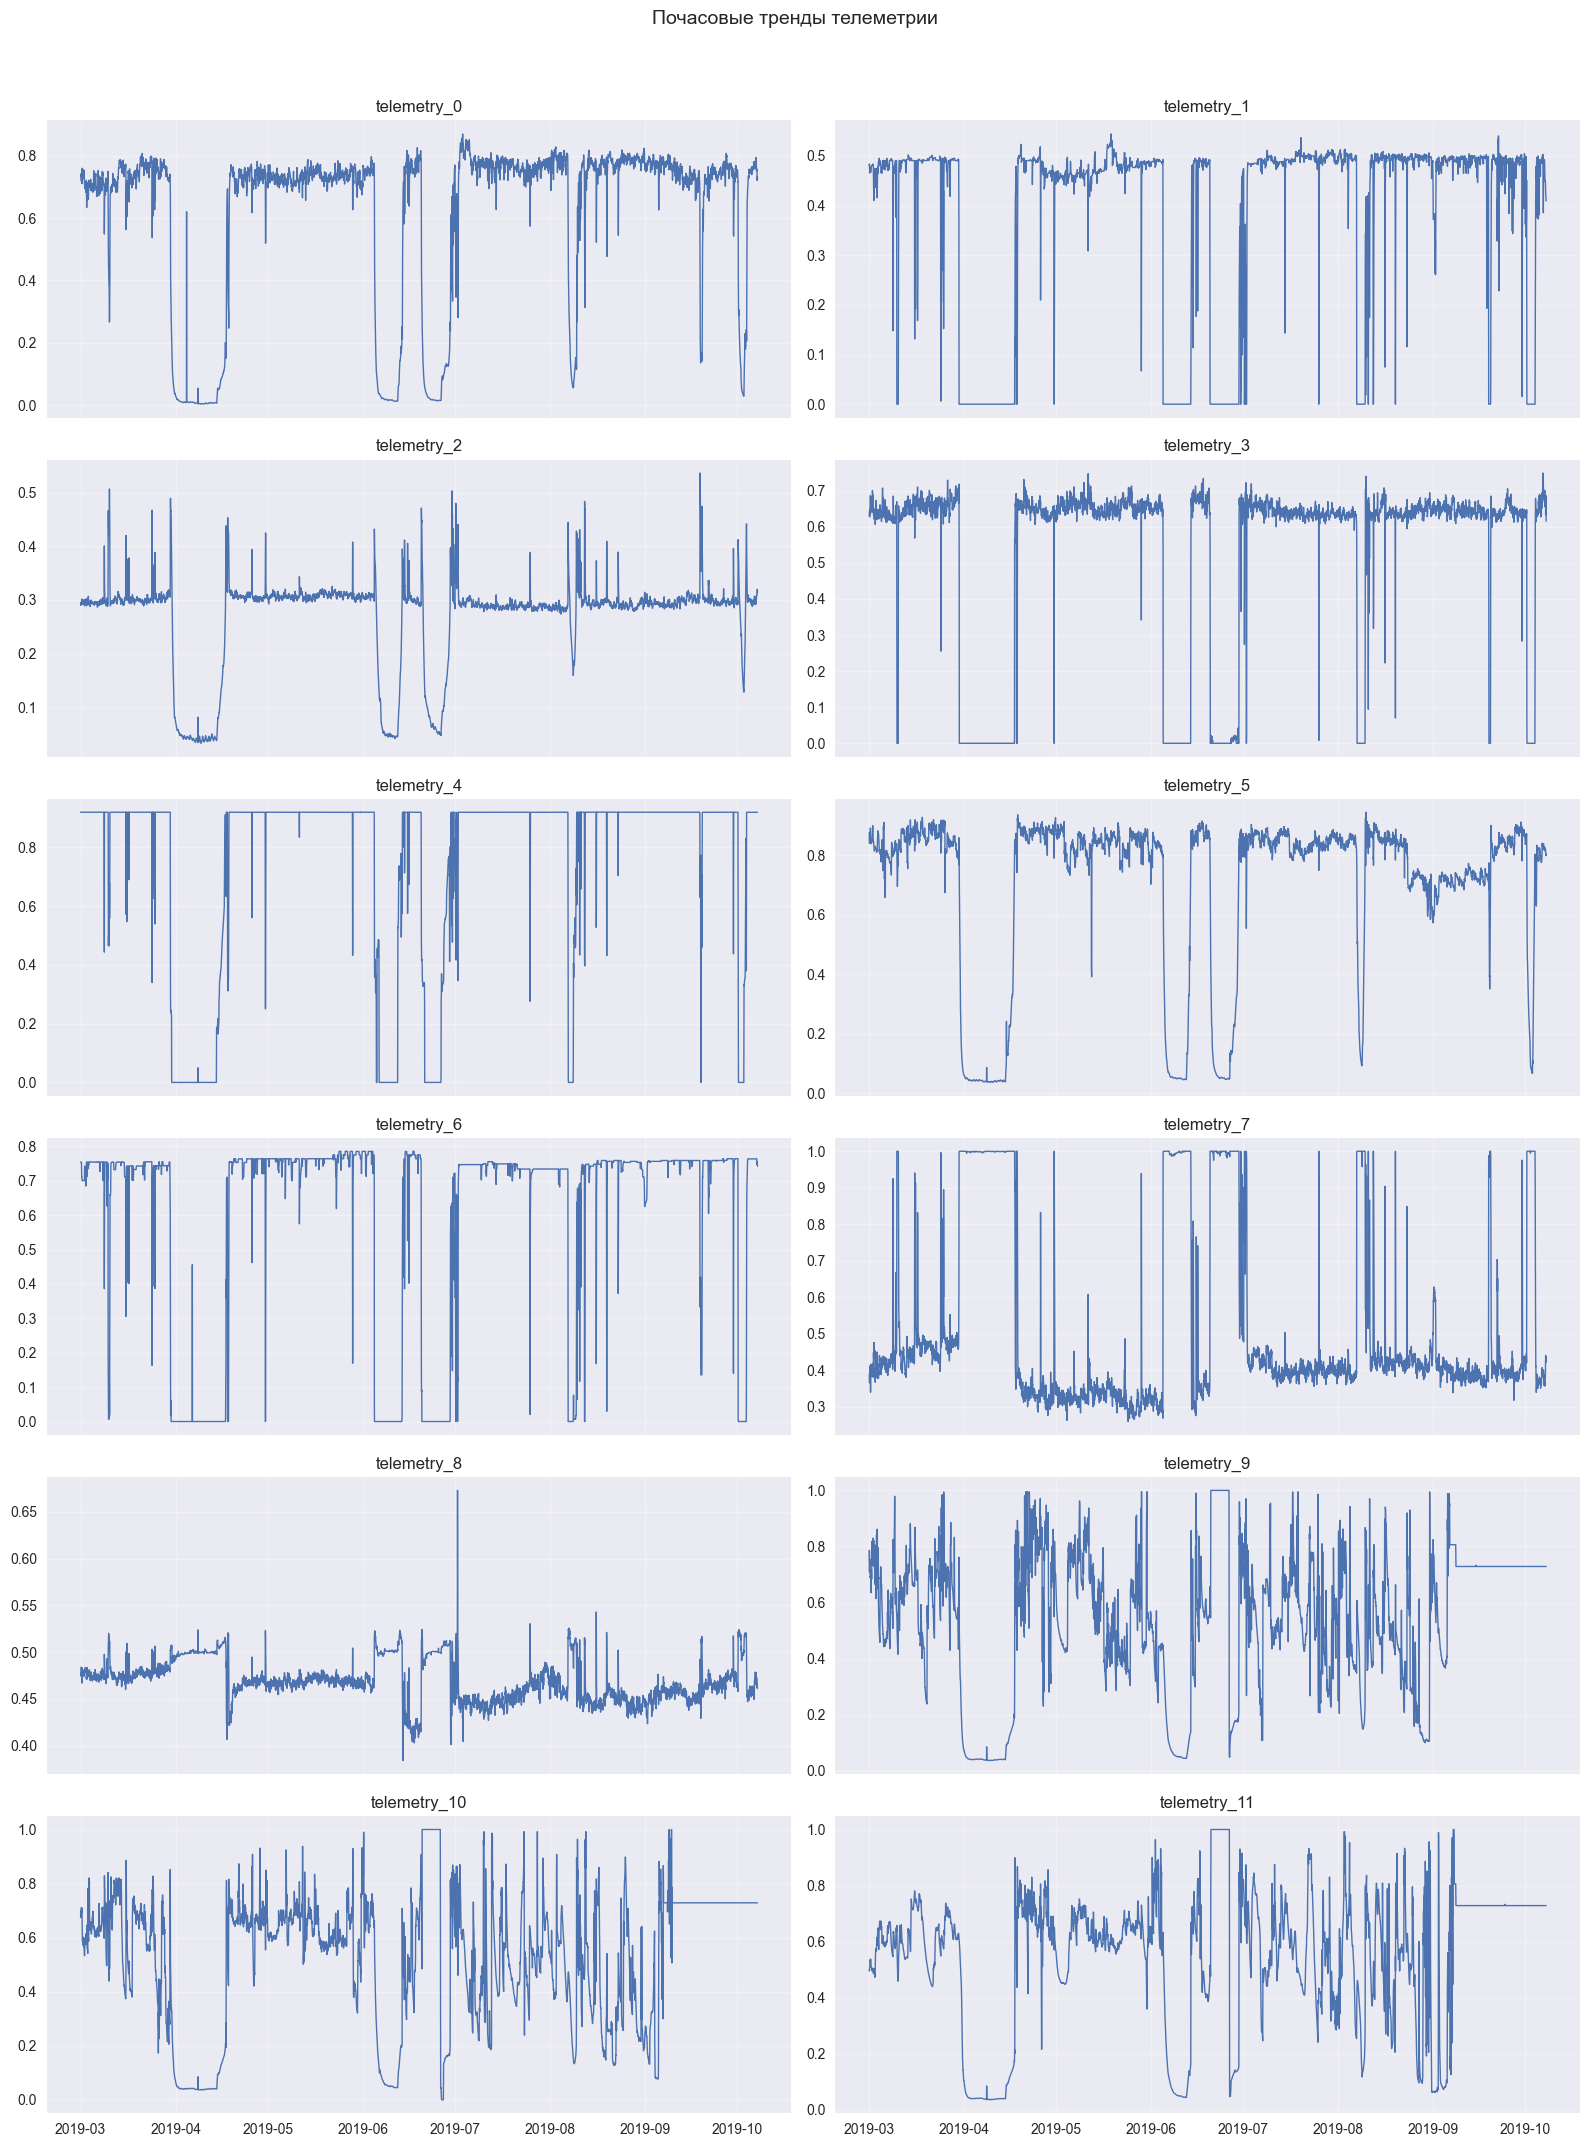

In [11]:
# Для длинного ряда удобно взять почасовое усреднение
df_hourly = (
    df.set_index("datetime")[telemetry_cols]
    .resample("1h")
    .mean()
)

n_cols = 2
n_rows = int(np.ceil(len(telemetry_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows), sharex=True)
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, telemetry_cols):
    ax.plot(df_hourly.index, df_hourly[col], linewidth=1)
    ax.set_title(col)
    ax.grid(True, alpha=0.3)

for ax in axes[len(telemetry_cols):]:
    ax.axis("off")

plt.suptitle("Почасовые тренды телеметрии", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


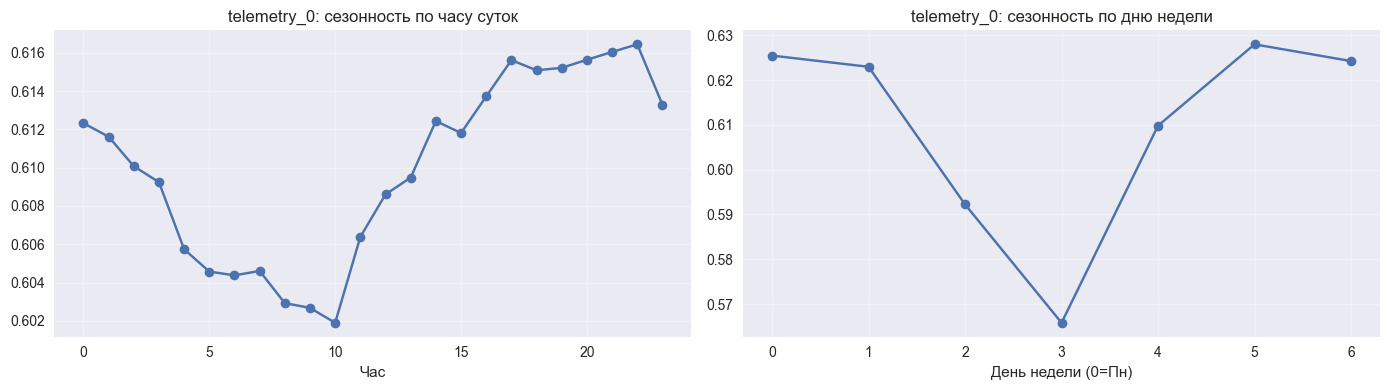

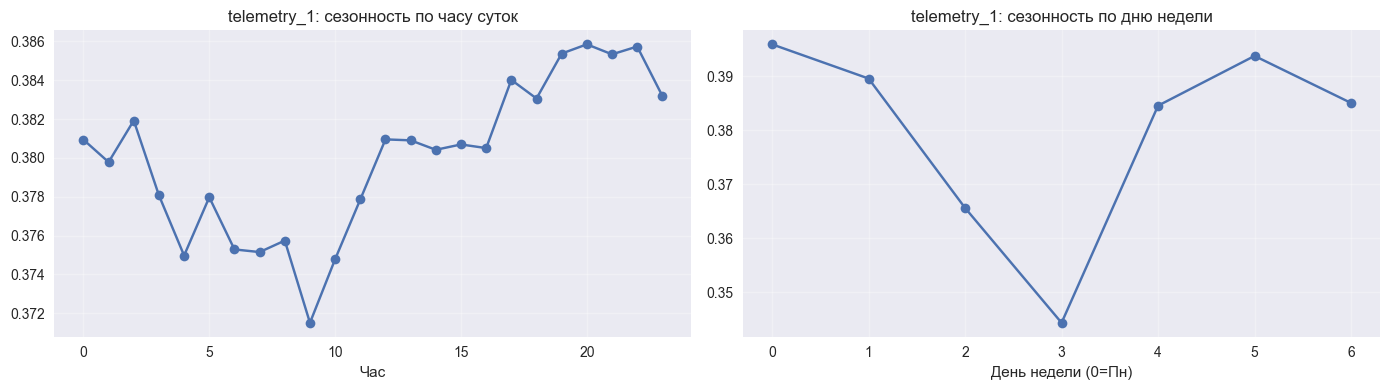

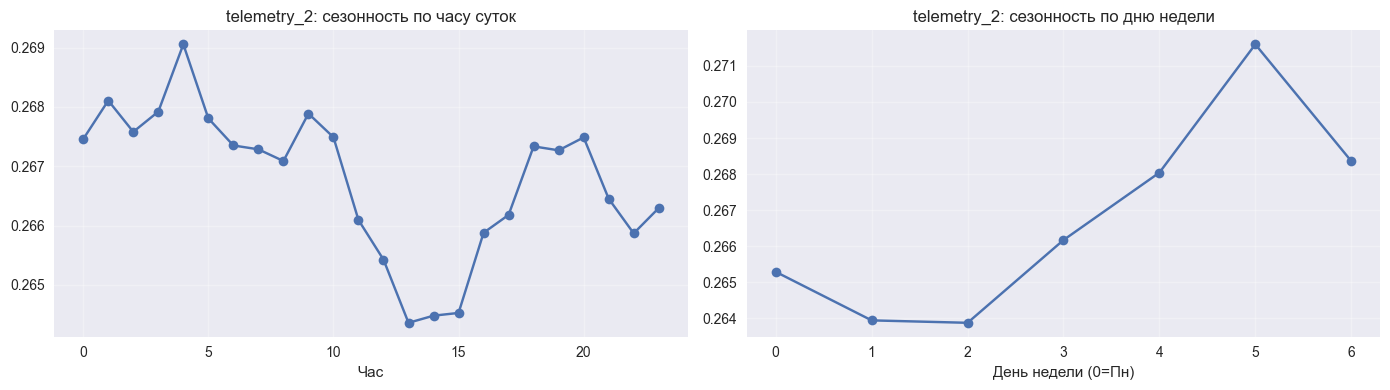

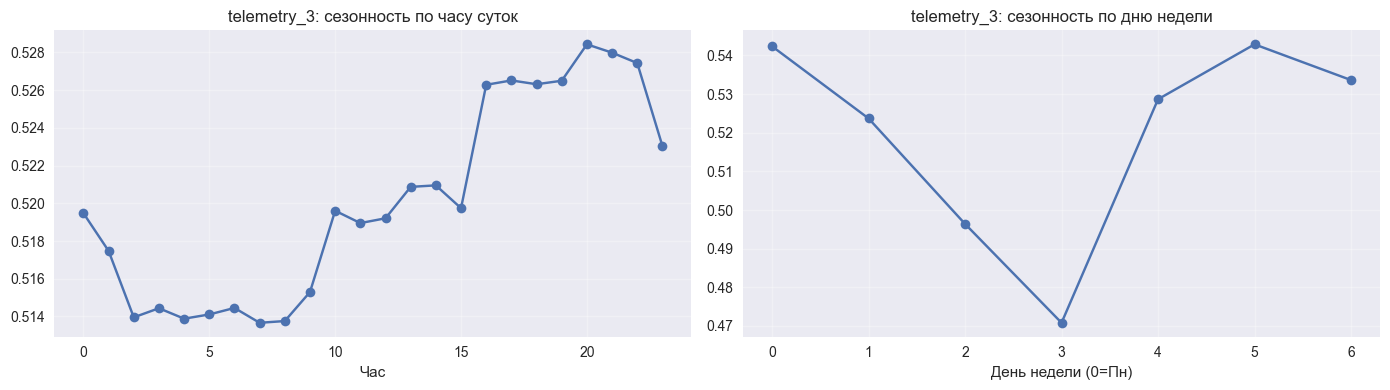

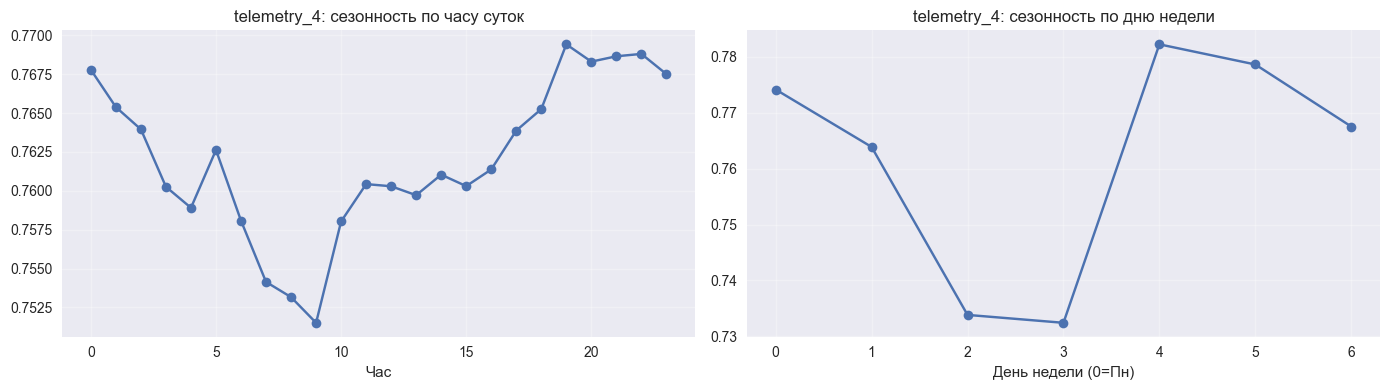

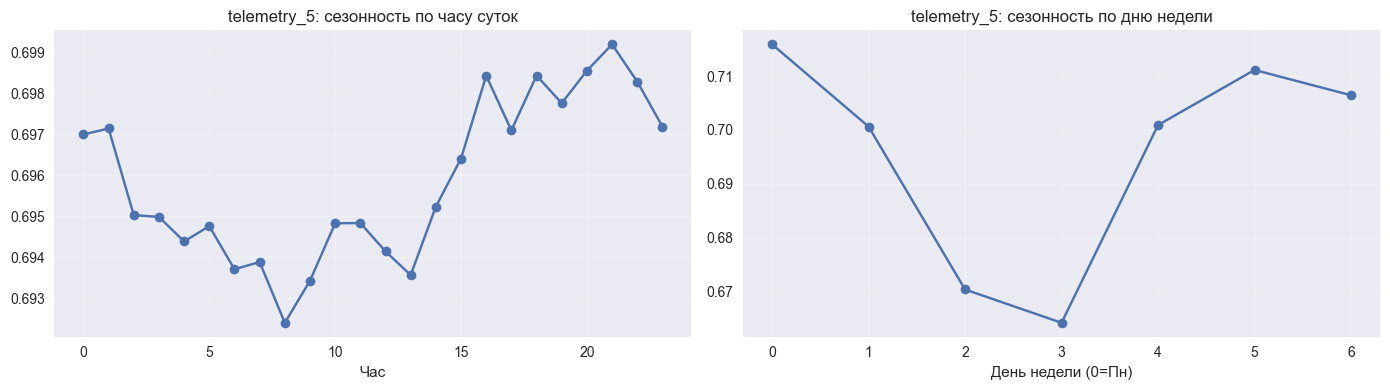

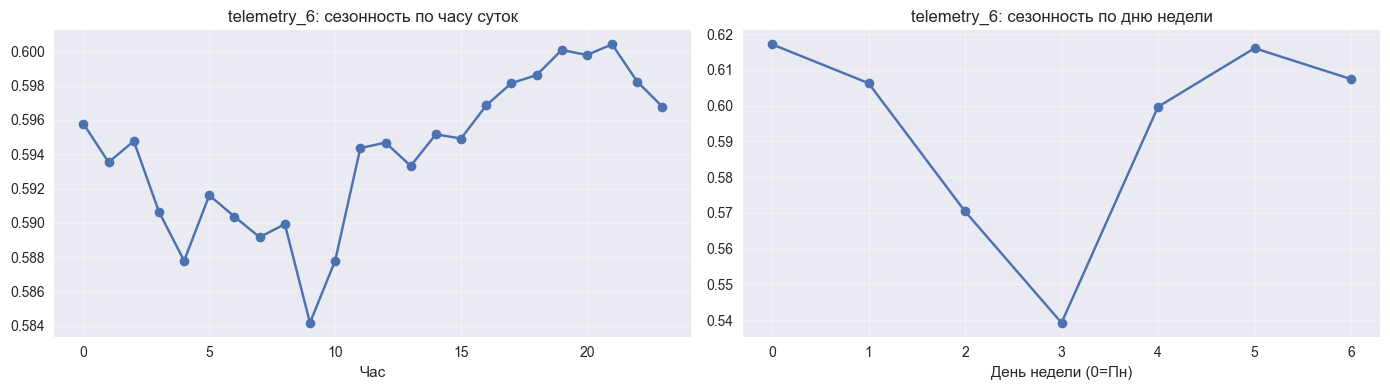

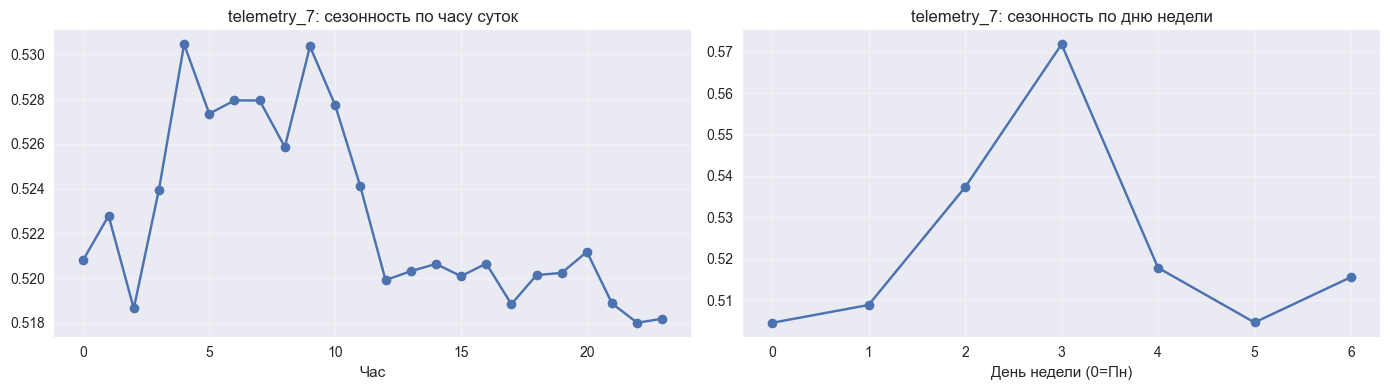

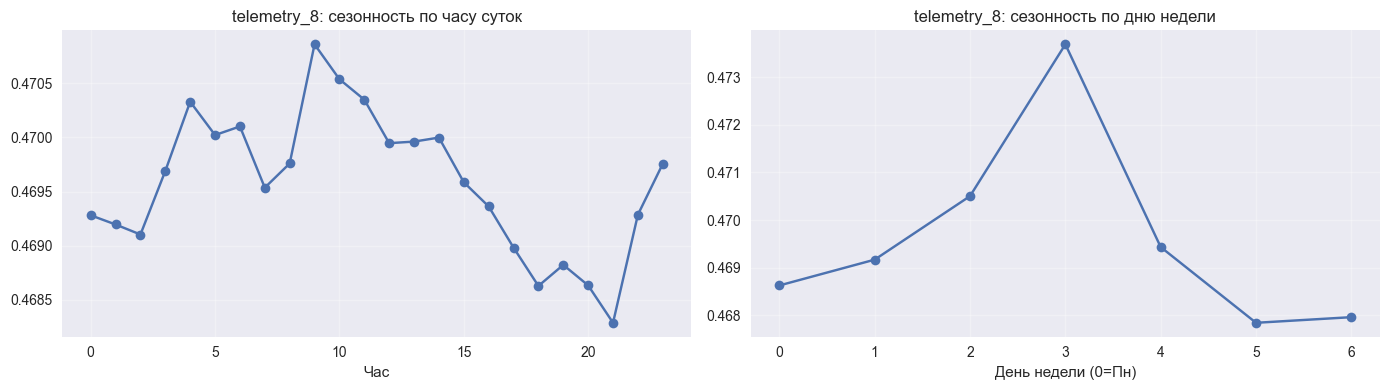

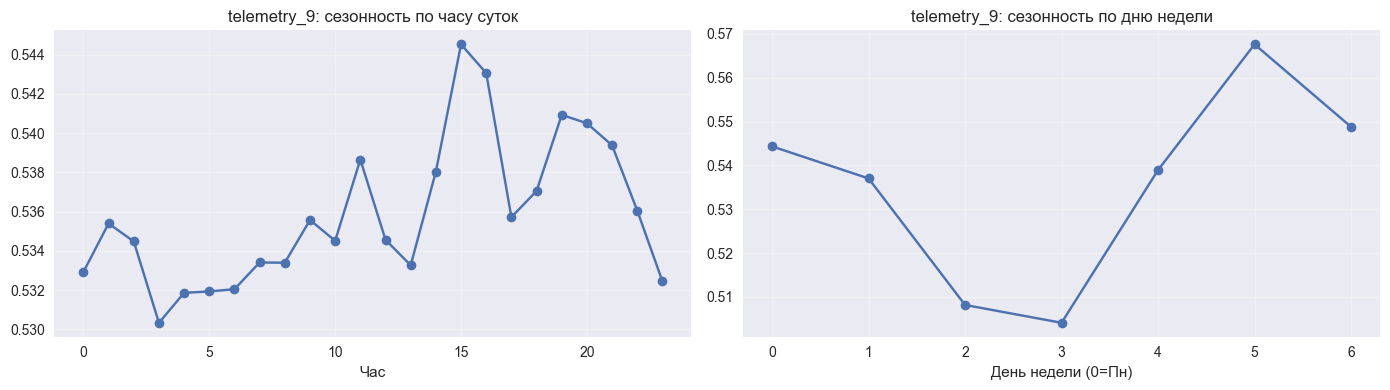

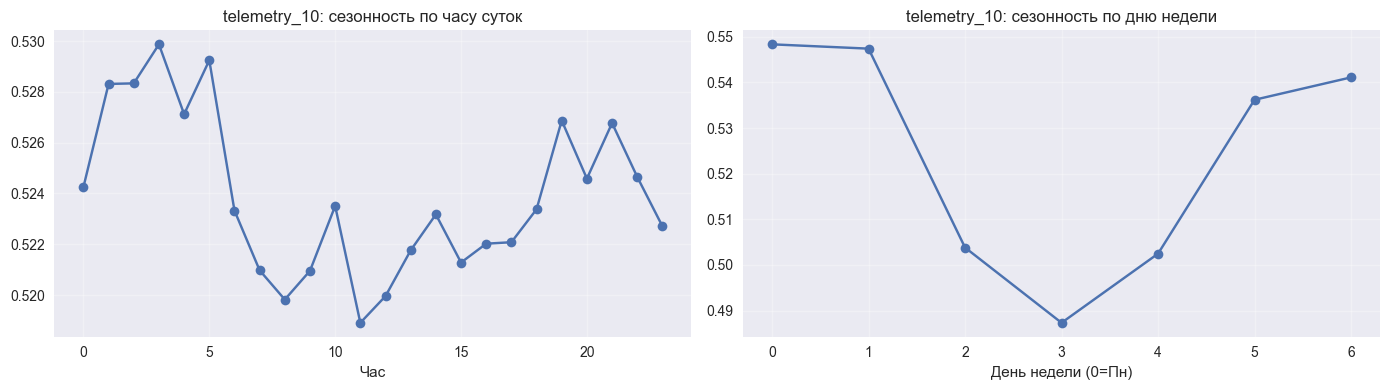

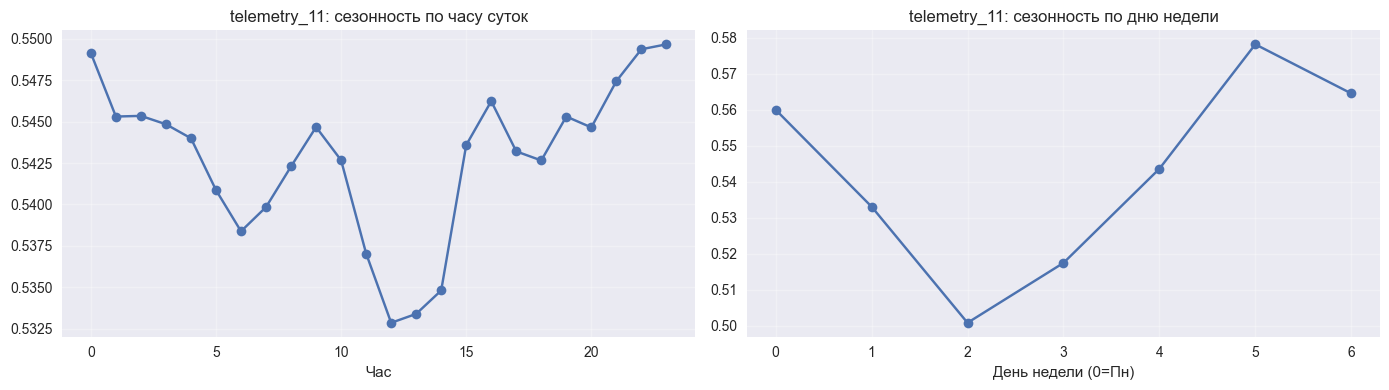

In [12]:
tmp = df.copy()
tmp["hour"] = tmp["datetime"].dt.hour
tmp["dayofweek"] = tmp["datetime"].dt.dayofweek

for col in telemetry_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    hourly_profile = tmp.groupby("hour")[col].mean()
    daily_profile = tmp.groupby("dayofweek")[col].mean()

    axes[0].plot(hourly_profile.index, hourly_profile.values, marker="o")
    axes[0].set_title(f"{col}: сезонность по часу суток")
    axes[0].set_xlabel("Час")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(daily_profile.index, daily_profile.values, marker="o")
    axes[1].set_title(f"{col}: сезонность по дню недели")
    axes[1].set_xlabel("День недели (0=Пн)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


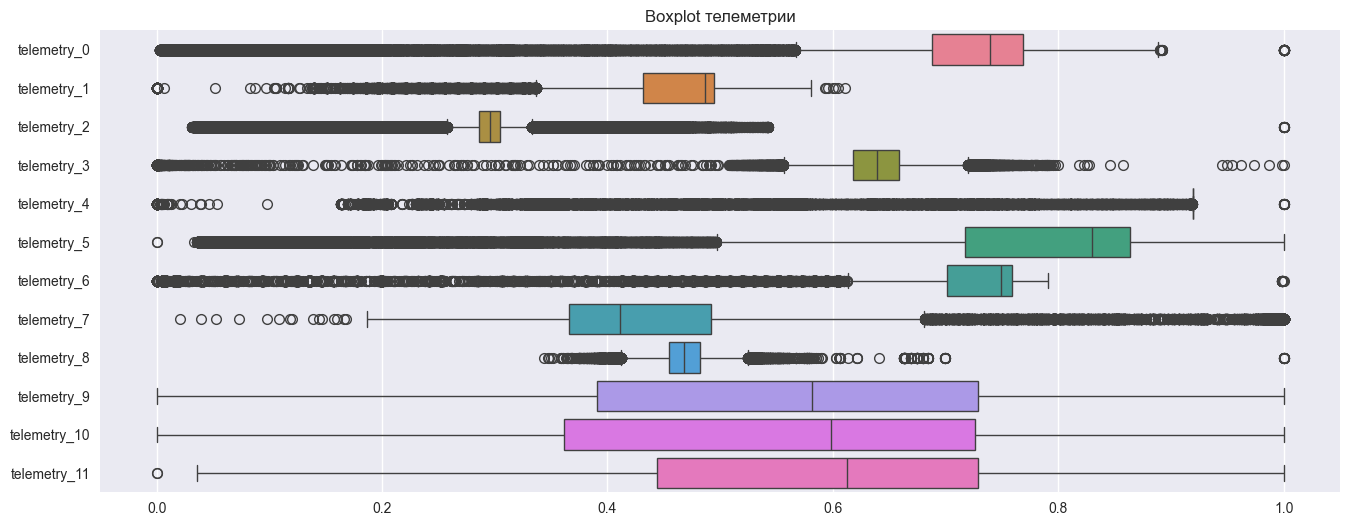

,feature,q1,q3,iqr,low_bound,high_bound,outlier_share
1,telemetry_1,0.431430,0.494401,0.062971,0.336974,0.588857,0.225698
6,telemetry_6,0.700847,0.759198,0.058350,0.613322,0.846723,0.220798
7,telemetry_7,0.366226,0.492155,0.125929,0.177333,0.681049,0.220081
4,telemetry_4,0.919214,0.919471,0.000257,0.918828,0.919857,0.213844
0,telemetry_0,0.687771,0.768498,0.080727,0.566680,0.889588,0.212987
2,telemetry_2,0.285872,0.304679,0.018807,0.257661,0.332890,0.212752
3,telemetry_3,0.617462,0.658350,0.040888,0.556131,0.719682,0.206089
5,telemetry_5,0.716705,0.863402,0.146697,0.496659,1.083448,0.179946
8,telemetry_8,0.454270,0.482336,0.028066,0.412170,0.524436,0.012549
11,telemetry_11,0.443616,0.728682,0.285066,0.016016,1.156282,0.000006


In [13]:
# Boxplot по признакам
plt.figure(figsize=(16, 6))
sns.boxplot(data=df[telemetry_cols], orient="h")
plt.title("Boxplot телеметрии")
plt.show()

# Доля выбросов по IQR
outlier_stats = []

for col in telemetry_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outlier_share = ((df[col] < low) | (df[col] > high)).mean()
    outlier_stats.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "low_bound": low,
        "high_bound": high,
        "outlier_share": outlier_share
    })

outlier_stats = pd.DataFrame(outlier_stats).sort_values("outlier_share", ascending=False)
display(outlier_stats)


count    1773.000000
mean        0.254272
std         0.092208
min         0.000000
25%         0.175258
50%         0.247423
75%         0.314433
max         0.716495
Name: target, dtype: float64

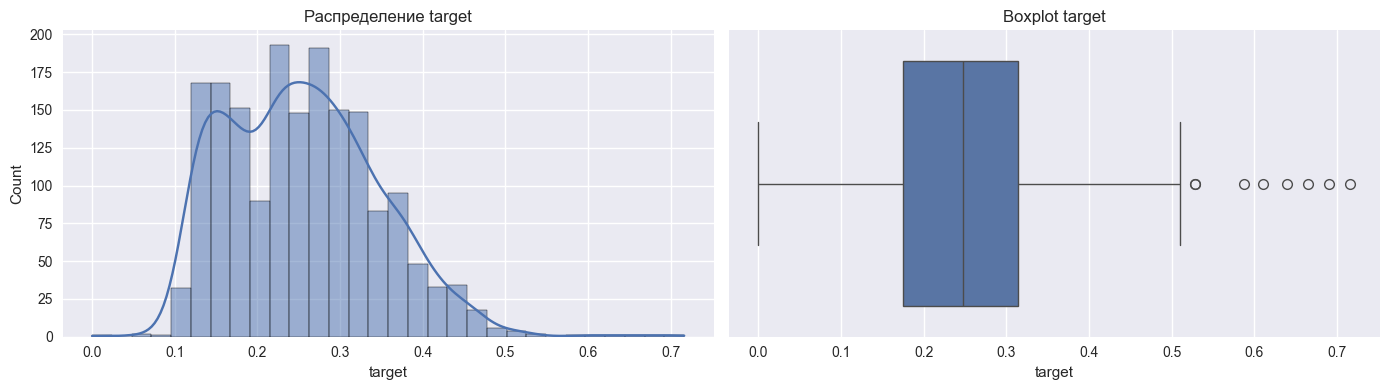

In [14]:
display(target["target"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(target["target"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Распределение target")

sns.boxplot(x=target["target"], ax=axes[1])
axes[1].set_title("Boxplot target")

plt.tight_layout()
plt.show()

count     1772.000000
mean       169.164786
std        784.088290
min         60.000000
25%        120.000000
50%        120.000000
75%        120.000000
max      26430.000000
Name: delta_min, dtype: float64

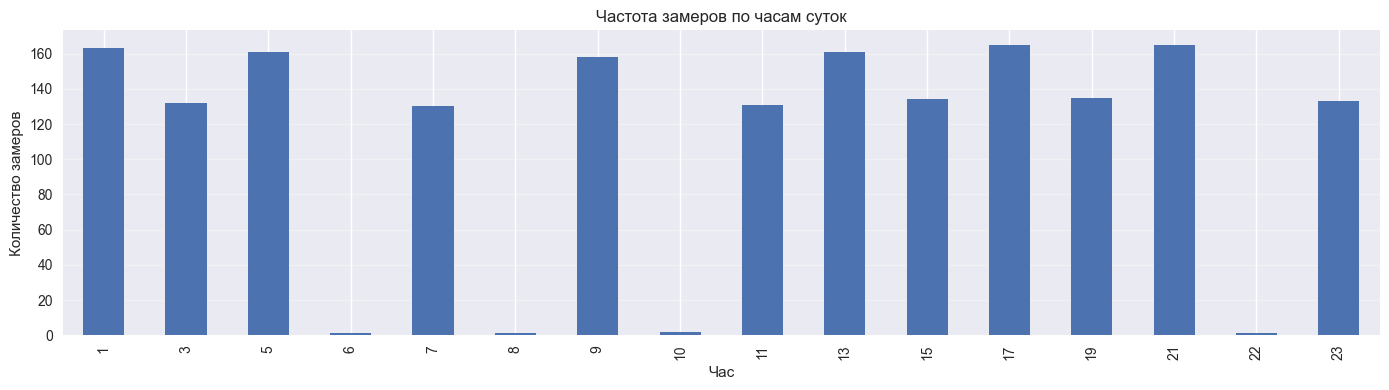

In [15]:
target = target.sort_values("lab_datetime").reset_index(drop=True)
target["delta_min"] = target["lab_datetime"].diff().dt.total_seconds() / 60

display(target["delta_min"].describe())

fig, ax = plt.subplots(figsize=(14, 4))

target["lab_datetime"].dt.hour.value_counts().sort_index().plot(kind="bar", ax=ax)

ax.set_title("Частота замеров по часам суток")
ax.set_xlabel("Час")
ax.set_ylabel("Количество замеров")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
# Предположение:
# lab_datetime = время получения результата из лаборатории
# тогда реальный момент отбора пробы был примерно на 10-15 минут раньше

target_sync = target.copy()
target_sync["sample_time_10m"] = target_sync["lab_datetime"] - pd.Timedelta(minutes=10)
target_sync["sample_time_12m"] = target_sync["lab_datetime"] - pd.Timedelta(minutes=12)
target_sync["sample_time_15m"] = target_sync["lab_datetime"] - pd.Timedelta(minutes=15)

display(target_sync.head())

,lab_datetime,target,delta_min,sample_time_10m,sample_time_12m,sample_time_15m
0,2019-03-13 17:00:00,0.123711,NaN,2019-03-13 16:50:00,2019-03-13 16:48:00,2019-03-13 16:45:00
1,2019-03-13 21:00:00,0.319588,240.0,2019-03-13 20:50:00,2019-03-13 20:48:00,2019-03-13 20:45:00
2,2019-03-14 01:00:00,0.255155,240.0,2019-03-14 00:50:00,2019-03-14 00:48:00,2019-03-14 00:45:00
3,2019-03-14 05:00:00,0.319588,240.0,2019-03-14 04:50:00,2019-03-14 04:48:00,2019-03-14 04:45:00
4,2019-03-14 09:00:00,0.159794,240.0,2019-03-14 08:50:00,2019-03-14 08:48:00,2019-03-14 08:45:00


In [17]:
# Жесткая синхронизация по предполагаемому времени отбора пробы
sync_12 = (
    df.merge(
        target_sync[["sample_time_12m", "lab_datetime", "target"]],
        left_on="datetime",
        right_on="sample_time_12m",
        how="inner"
    )
    .drop(columns=["sample_time_12m"])
)

print(sync_12.shape)
display(sync_12.head())


(1772, 19)


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15,lab_datetime,target
0,2019-03-13 16:48:00,0.787305,0.502351,0.308730,0.651176,0.919471,0.879027,0.754800,0.417424,0.474235,0.698382,0.767358,0.648041,NaN,NaN,NaN,NaN,2019-03-13 17:00:00,0.123711
1,2019-03-13 20:48:00,0.782386,0.497251,0.301207,0.655321,0.919471,0.856169,0.754800,0.470685,0.480600,0.712567,0.750949,0.629684,NaN,NaN,NaN,NaN,2019-03-13 21:00:00,0.319588
2,2019-03-14 00:48:00,0.787305,0.497028,0.300339,0.633237,0.919471,0.876712,0.753513,0.443848,0.480022,0.706726,0.760683,0.642756,NaN,NaN,NaN,NaN,2019-03-14 01:00:00,0.255155
3,2019-03-14 04:48:00,0.749401,0.490628,0.298892,0.646602,0.919471,0.837651,0.752977,0.425268,0.474235,0.779596,0.781821,0.610493,NaN,NaN,NaN,NaN,2019-03-14 05:00:00,0.319588
4,2019-03-14 08:48:00,0.767919,0.493395,0.301496,0.675525,0.919471,0.844306,0.752977,0.434352,0.464397,0.863869,0.767914,0.581012,NaN,NaN,NaN,NaN,2019-03-14 09:00:00,0.159794


In [18]:
# Посмотрим, какой лаг дает наибольшую корреляцию с target
lag_results = []

for lag in range(5, 21):  # от 5 до 20 минут
    tmp_target = target.copy()
    tmp_target["sample_time"] = tmp_target["lab_datetime"] - pd.Timedelta(minutes=lag)

    tmp_sync = pd.merge_asof(
        left=tmp_target.sort_values("sample_time"),
        right=df.sort_values("datetime"),
        left_on="sample_time",
        right_on="datetime",
        direction="nearest",
        tolerance=pd.Timedelta("1min")
    )

    row = {"lag_min": lag}
    for col in telemetry_cols:
        row[col] = tmp_sync[[col, "target"]].corr().iloc[0, 1]
    lag_results.append(row)

lag_corr = pd.DataFrame(lag_results)
display(lag_corr.head())

best_lag_by_abs_corr = (
    lag_corr.set_index("lag_min")
    .abs()
    .idxmax()
    .to_frame("best_lag_min")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(best_lag_by_abs_corr)


,lag_min,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11
0,5,-0.186639,-0.044691,-0.005222,-0.101225,-0.082470,-0.065666,-0.084509,-0.042919,0.097322,-0.123083,-0.068948,-0.087819
1,6,-0.185424,-0.052869,-0.005293,-0.099417,-0.079788,-0.068541,-0.092510,-0.042505,0.096149,-0.123082,-0.069380,-0.088437
2,7,-0.185824,-0.045944,-0.006475,-0.111162,-0.079895,-0.069327,-0.090442,-0.049083,0.096609,-0.122265,-0.069865,-0.088638
3,8,-0.185609,-0.040237,-0.007012,-0.103118,-0.082541,-0.070615,-0.092122,-0.045813,0.091790,-0.122280,-0.069708,-0.089737
4,9,-0.184897,-0.041693,-0.008372,-0.112908,-0.076378,-0.071849,-0.094441,-0.047980,0.090423,-0.122031,-0.070866,-0.089978


,feature,best_lag_min
0,telemetry_0,5
1,telemetry_1,6
2,telemetry_2,12
3,telemetry_3,18
4,telemetry_4,8
5,telemetry_5,11
6,telemetry_6,10
7,telemetry_7,7
8,telemetry_8,18
9,telemetry_9,5


,corr_with_target
telemetry_0,-0.180212
telemetry_3,-0.125249
telemetry_9,-0.121268
telemetry_6,-0.092597
telemetry_11,-0.090234
telemetry_8,0.089205
telemetry_4,-0.077157
telemetry_10,-0.071572
telemetry_5,-0.070636
telemetry_7,-0.045499


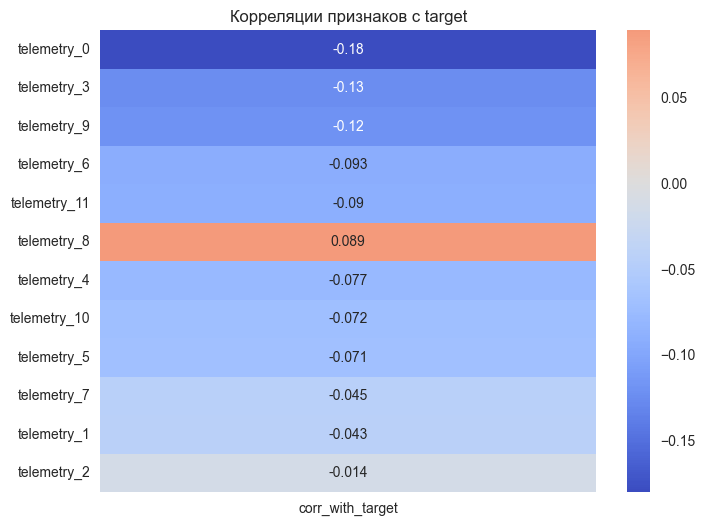

In [19]:
eda_sync = sync_12.dropna(subset=["datetime"]).copy()

corr_with_target = (
    eda_sync[telemetry_cols + ["target"]]
    .corr()["target"]
    .drop("target")
    .sort_values(key=np.abs, ascending=False)
    .to_frame("corr_with_target")
)

display(corr_with_target)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_with_target, annot=True, cmap="coolwarm", center=0)
plt.title("Корреляции признаков с target")
plt.show()


## Обоснование стратегии обработки пропусков и аномалий

### 1. Пропуски в телеметрии

По результатам EDA пропуски в большинстве телеметрических признаков единичны и составляют доли процента. Это означает, что они, скорее всего, связаны не с изменением технологического режима, а с кратковременными сбоями датчиков, передачи данных или записи в систему. Для таких пропусков допустимо использовать локальное восстановление значений, например `forward fill`, линейную интерполяцию по времени или заполнение на основе ближайших соседних измерений. В условиях промышленного процесса это оправдано, потому что параметры печи обычно меняются инерционно, а значит на коротком горизонте соседние значения хорошо аппроксимируют истинное состояние процесса.

Отдельно выделяются признаки `telemetry_12`-`telemetry_15`, у которых доля пропусков составляет около 99%. Такие признаки нельзя надежно восстанавливать, так как в данных практически отсутствует информационная основа для заполнения. В производственном контексте это больше похоже не на случайные пропуски, а на неработающие или поздно введенные в эксплуатацию датчики. Поэтому оптимальная стратегия — исключить эти признаки из моделирования или использовать только в том случае, если будет подтверждено, что в тестовых и будущих эксплуатационных данных они реально заполняются.

### 2. Пропуски в целевой переменной

Целевая переменная измеряется лабораторно и поступает нерегулярно, в основном раз в 2 часа, при этом присутствуют отдельные большие временные разрывы. Такие пропуски нельзя заполнять интерполяцией, потому что целевой показатель не является прямым онлайн-сигналом: он отражает результат физико-химического анализа пробы, взятой из печи с задержкой 10-15 минут. Искусственное заполнение пропусков привело бы к появлению псевдо-наблюдений, не подтвержденных лабораторией, и внесло бы систематическую ошибку в модель.

Поэтому для обучения следует использовать только реальные лабораторные замеры, а для синхронизации с телеметрией сопоставлять каждому замеру состояние печи в предполагаемый момент отбора пробы, то есть за 10-15 минут до времени получения результата.

### 3. Аномалии в телеметрии

В промышленном процессе выбросы нельзя автоматически считать ошибками. Резкие скачки значений могут отражать реальные переходные режимы, нарушения хода процесса, изменения подачи сырья, корректировки оператором или начало нештатной ситуации. Именно такие состояния особенно важны для построения виртуального датчика, так как модель должна уметь реагировать не только на "нормальный" режим, но и на приближение отклонений качества.

Поэтому стратегия должна быть осторожной:
- не удалять все статистические выбросы автоматически;
- сначала отделять явные артефакты датчиков от технологически правдоподобных скачков;
- использовать мягкую обработку только для явных ошибок измерения, например для невозможных значений, обрывов сигнала или одиночных спайков, резко отличающихся от соседних минут;
- при необходимости добавлять бинарные флаги аномальности как отдельные признаки, а не просто сглаживать все нестандартные точки.

### 4. Практическая стратегия для дальнейшего моделирования

На основании EDA разумно принять следующую стратегию подготовки данных:

1. Признаки `telemetry_12`-`telemetry_15` исключить из анализа из-за почти полной отсутствующей заполненности.
2. Для остальных телеметрических признаков короткие пропуски восстанавливать локально во временном ряду.
3. Целевую переменную не заполнять и не интерполировать.
4. При формировании обучающей выборки учитывать временную задержку лабораторного анализа и использовать лаги телеметрии.
5. Аномальные значения не удалять безусловно; сначала проверять их на технологическую интерпретируемость.
6. Для явно ошибочных выбросов использовать мягкое ограничение или замену на локально восстановленные значения, сохраняя информацию о факте аномалии в отдельном признаке.

### 5. Вывод

В данной задаче пропуски и аномалии являются не только проблемой качества данных, но и потенциальным источником информации о состоянии производственного процесса. Поэтому обработка должна быть не агрессивной, а технологически интерпретируемой: краткие пропуски телеметрии можно восстанавливать, почти пустые признаки исключать, лабораторный target не заполнять, а выбросы анализировать как возможные проявления нештатных режимов, а не только как шум.


# Инжиниринг признаков для временных рядов

In [20]:
# Выберем ключевые telemetry-признаки по модулю корреляции с target
top_n = 5

key_telemetry_cols = (
    corr_with_target["corr_with_target"]
    .abs()
    .sort_values(ascending=False)
    .head(top_n)
    .index
    .tolist()
)

print("Ключевые telemetry-признаки:")
print(key_telemetry_cols)


Ключевые telemetry-признаки:
['telemetry_0', 'telemetry_3', 'telemetry_9', 'telemetry_6', 'telemetry_11']


In [21]:
# Создаём лаговые признаки для ключевых telemetry-показателей
df_lagged = df.sort_values("datetime").copy()

lags = [1, 2, 3, 6, 12]  # если шаг 1 минута: 1,2,3,6,12 минут назад

for col in key_telemetry_cols:
    for lag in lags:
        df_lagged[f"{col}_lag_{lag}"] = df_lagged[col].shift(lag)

lag_feature_cols = [
    f"{col}_lag_{lag}"
    for col in key_telemetry_cols
    for lag in lags
]

print("Размер после создания лагов:", df_lagged.shape)
display(df_lagged[["datetime"] + key_telemetry_cols + lag_feature_cols].head(10))


Размер после создания лагов: (319546, 42)


,datetime,telemetry_0,telemetry_3,telemetry_9,telemetry_6,telemetry_11,telemetry_0_lag_1,telemetry_0_lag_2,telemetry_0_lag_3,telemetry_0_lag_6,telemetry_0_lag_12,telemetry_3_lag_1,telemetry_3_lag_2,telemetry_3_lag_3,telemetry_3_lag_6,telemetry_3_lag_12,telemetry_9_lag_1,telemetry_9_lag_2,telemetry_9_lag_3,telemetry_9_lag_6,telemetry_9_lag_12,telemetry_6_lag_1,telemetry_6_lag_2,telemetry_6_lag_3,telemetry_6_lag_6,telemetry_6_lag_12,telemetry_11_lag_1,telemetry_11_lag_2,telemetry_11_lag_3,telemetry_11_lag_6,telemetry_11_lag_12
0,2019-03-01 00:01:00,0.737538,0.644016,0.677801,0.754800,0.498407,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,0.738406,0.648557,0.677801,0.752977,0.498407,0.737538,NaN,NaN,NaN,NaN,0.644016,NaN,NaN,NaN,NaN,0.677801,NaN,NaN,NaN,NaN,0.754800,NaN,NaN,NaN,NaN,0.498407,NaN,NaN,NaN,NaN
2,2019-03-01 00:03:00,0.738985,0.647164,0.677801,0.755444,0.498407,0.738406,0.737538,NaN,NaN,NaN,0.648557,0.644016,NaN,NaN,NaN,0.677801,0.677801,NaN,NaN,NaN,0.752977,0.754800,NaN,NaN,NaN,0.498407,0.498407,NaN,NaN,NaN
3,2019-03-01 00:04:00,0.739563,0.636938,0.678079,0.754800,0.498407,0.738985,0.738406,0.737538,NaN,NaN,0.647164,0.648557,0.644016,NaN,NaN,0.677801,0.677801,0.677801,NaN,NaN,0.755444,0.752977,0.754800,NaN,NaN,0.498407,0.498407,0.498407,NaN,NaN
4,2019-03-01 00:05:00,0.740431,0.635834,0.678357,0.754156,0.498407,0.739563,0.738985,0.738406,NaN,NaN,0.636938,0.647164,0.648557,NaN,NaN,0.678079,0.677801,0.677801,NaN,NaN,0.754800,0.755444,0.752977,NaN,NaN,0.498407,0.498407,0.498407,NaN,NaN
5,2019-03-01 00:06:00,0.740721,0.633492,0.678357,0.754156,0.498407,0.740431,0.739563,0.738985,NaN,NaN,0.635834,0.636938,0.647164,NaN,NaN,0.678357,0.678079,0.677801,NaN,NaN,0.754156,0.754800,0.755444,NaN,NaN,0.498407,0.498407,0.498407,NaN,NaN
6,2019-03-01 00:07:00,0.741299,0.645671,0.678357,0.753513,0.498407,0.740721,0.740431,0.739563,0.737538,NaN,0.633492,0.635834,0.636938,0.644016,NaN,0.678357,0.678357,0.678079,0.677801,NaN,0.754156,0.754156,0.754800,0.754800,NaN,0.498407,0.498407,0.498407,0.498407,NaN
7,2019-03-01 00:08:00,0.742457,0.656781,0.678357,0.754156,0.498407,0.741299,0.740721,0.740431,0.738406,NaN,0.645671,0.633492,0.635834,0.648557,NaN,0.678357,0.678357,0.678357,0.677801,NaN,0.753513,0.754156,0.754156,0.752977,NaN,0.498407,0.498407,0.498407,0.498407,NaN
8,2019-03-01 00:09:00,0.742746,0.657516,0.678357,0.755444,0.498407,0.742457,0.741299,0.740721,0.738985,NaN,0.656781,0.645671,0.633492,0.647164,NaN,0.678357,0.678357,0.678357,0.677801,NaN,0.754156,0.753513,0.754156,0.755444,NaN,0.498407,0.498407,0.498407,0.498407,NaN
9,2019-03-01 00:10:00,0.743325,0.658300,0.679748,0.754156,0.498407,0.742746,0.742457,0.741299,0.739563,NaN,0.657516,0.656781,0.645671,0.636938,NaN,0.678357,0.678357,0.678357,0.678079,NaN,0.755444,0.754156,0.753513,0.754800,NaN,0.498407,0.498407,0.498407,0.498407,NaN


In [22]:
# Синхронизируем target с telemetry + lag features
model_data = (
    pd.merge_asof(
        left=target_sync[["lab_datetime", "sample_time_12m", "target"]].sort_values("sample_time_12m"),
        right=df_lagged.sort_values("datetime"),
        left_on="sample_time_12m",
        right_on="datetime",
        direction="nearest",
        tolerance=pd.Timedelta("1min")
    )
)

print("Размер итоговой таблицы:", model_data.shape)
display(model_data.head())


Размер итоговой таблицы: (1773, 45)


,lab_datetime,sample_time_12m,target,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15,telemetry_0_lag_1,telemetry_0_lag_2,telemetry_0_lag_3,telemetry_0_lag_6,telemetry_0_lag_12,telemetry_3_lag_1,telemetry_3_lag_2,telemetry_3_lag_3,telemetry_3_lag_6,telemetry_3_lag_12,telemetry_9_lag_1,telemetry_9_lag_2,telemetry_9_lag_3,telemetry_9_lag_6,telemetry_9_lag_12,telemetry_6_lag_1,telemetry_6_lag_2,telemetry_6_lag_3,telemetry_6_lag_6,telemetry_6_lag_12,telemetry_11_lag_1,telemetry_11_lag_2,telemetry_11_lag_3,telemetry_11_lag_6,telemetry_11_lag_12
0,2019-03-13 17:00:00,2019-03-13 16:48:00,0.123711,2019-03-13 16:48:00,0.787305,0.502351,0.308730,0.651176,0.919471,0.879027,0.754800,0.417424,0.474235,0.698382,0.767358,0.648041,NaN,NaN,NaN,NaN,0.787305,0.787305,0.787016,0.786726,0.785280,0.653421,0.648530,0.640194,0.641707,0.640719,0.697826,0.697826,0.697826,0.697826,0.697548,0.754800,0.752977,0.753513,0.752977,0.754800,0.648041,0.648041,0.648041,0.648041,0.647763
1,2019-03-13 21:00:00,2019-03-13 20:48:00,0.319588,2019-03-13 20:48:00,0.782386,0.497251,0.301207,0.655321,0.919471,0.856169,0.754800,0.470685,0.480600,0.712567,0.750949,0.629684,NaN,NaN,NaN,NaN,0.782386,0.782386,0.782386,0.781807,0.777467,0.653266,0.640334,0.648751,0.640504,0.648199,0.712567,0.712567,0.712567,0.712011,0.712011,0.753513,0.754156,0.755444,0.752977,0.754800,0.629684,0.629684,0.629406,0.629406,0.628850
2,2019-03-14 01:00:00,2019-03-14 00:48:00,0.255155,2019-03-14 00:48:00,0.787305,0.497028,0.300339,0.633237,0.919471,0.876712,0.753513,0.443848,0.480022,0.706726,0.760683,0.642756,NaN,NaN,NaN,NaN,0.787594,0.788173,0.788462,0.789620,0.793092,0.638126,0.636526,0.633713,0.650629,0.657542,0.706726,0.705614,0.705614,0.705614,0.705335,0.754156,0.752977,0.753513,0.752333,0.754800,0.642756,0.642756,0.642756,0.642478,0.642756
3,2019-03-14 05:00:00,2019-03-14 04:48:00,0.319588,2019-03-14 04:48:00,0.749401,0.490628,0.298892,0.646602,0.919471,0.837651,0.752977,0.425268,0.474235,0.779596,0.781821,0.610493,NaN,NaN,NaN,NaN,0.749690,0.749980,0.749980,0.750558,0.754320,0.639920,0.643213,0.641410,0.643548,0.637977,0.779596,0.778205,0.777927,0.778205,0.778205,0.752333,0.753513,0.752977,0.754800,0.755444,0.610493,0.610493,0.610772,0.611884,0.612162
4,2019-03-14 09:00:00,2019-03-14 08:48:00,0.159794,2019-03-14 08:48:00,0.767919,0.493395,0.301496,0.675525,0.919471,0.844306,0.752977,0.434352,0.464397,0.863869,0.767914,0.581012,NaN,NaN,NaN,NaN,0.768498,0.768787,0.769655,0.770812,0.772259,0.677444,0.666339,0.659894,0.673259,0.681054,0.863869,0.862478,0.861088,0.854134,0.837447,0.754156,0.753513,0.752977,0.752977,0.752333,0.581012,0.581012,0.581290,0.582402,0.582402


In [23]:
# Скользящие статистики по ключевым telemetry-признакам
df_features = df_lagged.sort_values("datetime").copy()

windows = [3, 6, 12, 24]  # если шаг телеметрии 1 минута, то это окна в минутах

for col in key_telemetry_cols:
    for w in windows:
        rolling_obj = df_features[col].rolling(window=w, min_periods=w)

        df_features[f"{col}_roll_mean_{w}"] = rolling_obj.mean()
        df_features[f"{col}_roll_std_{w}"] = rolling_obj.std()
        df_features[f"{col}_roll_min_{w}"] = rolling_obj.min()
        df_features[f"{col}_roll_max_{w}"] = rolling_obj.max()

rolling_feature_cols = [
    f"{col}_roll_{stat}_{w}"
    for col in key_telemetry_cols
    for w in windows
    for stat in ["mean", "std", "min", "max"]
]

print("Добавлены скользящие статистики")
print("Размер таблицы:", df_features.shape)
display(df_features[["datetime"] + rolling_feature_cols[:12]].head(10))


Добавлены скользящие статистики
Размер таблицы: (319546, 122)


,datetime,telemetry_0_roll_mean_3,telemetry_0_roll_std_3,telemetry_0_roll_min_3,telemetry_0_roll_max_3,telemetry_0_roll_mean_6,telemetry_0_roll_std_6,telemetry_0_roll_min_6,telemetry_0_roll_max_6,telemetry_0_roll_mean_12,telemetry_0_roll_std_12,telemetry_0_roll_min_12,telemetry_0_roll_max_12
0,2019-03-01 00:01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-03-01 00:03:00,0.738309,0.000728,0.737538,0.738985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-03-01 00:04:00,0.738985,0.000579,0.738406,0.739563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-03-01 00:05:00,0.739660,0.000728,0.738985,0.740431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2019-03-01 00:06:00,0.740238,0.000602,0.739563,0.740721,0.739274,0.001214,0.737538,0.740721,NaN,NaN,NaN,NaN
6,2019-03-01 00:07:00,0.740817,0.000442,0.740431,0.741299,0.739901,0.001104,0.738406,0.741299,NaN,NaN,NaN,NaN
7,2019-03-01 00:08:00,0.741492,0.000884,0.740721,0.742457,0.740576,0.001238,0.738985,0.742457,NaN,NaN,NaN,NaN
8,2019-03-01 00:09:00,0.742167,0.000766,0.741299,0.742746,0.741203,0.001223,0.739563,0.742746,NaN,NaN,NaN,NaN
9,2019-03-01 00:10:00,0.742842,0.000442,0.742457,0.743325,0.741830,0.001178,0.740431,0.743325,NaN,NaN,NaN,NaN


In [24]:
# Признаки динамики изменений
diff_periods = [1, 3, 6]

for col in key_telemetry_cols:
    for p in diff_periods:
        # Абсолютное изменение
        df_features[f"{col}_diff_{p}"] = df_features[col].diff(p)

        # Относительное изменение / темп роста
        prev = df_features[col].shift(p)
        df_features[f"{col}_growth_rate_{p}"] = (df_features[col] - prev) / (prev.abs() + 1e-6)

        # "Производная" как изменение в единицу шага
        df_features[f"{col}_derivative_{p}"] = df_features[col].diff(p) / p

dynamic_feature_cols = [
    f"{col}_{feature}_{p}"
    for col in key_telemetry_cols
    for p in diff_periods
    for feature in ["diff", "growth_rate", "derivative"]
]

print("Добавлены признаки динамики")
print("Размер таблицы:", df_features.shape)
display(df_features[["datetime"] + dynamic_feature_cols[:12]].head(10))


Добавлены признаки динамики
Размер таблицы: (319546, 167)


,datetime,telemetry_0_diff_1,telemetry_0_growth_rate_1,telemetry_0_derivative_1,telemetry_0_diff_3,telemetry_0_growth_rate_3,telemetry_0_derivative_3,telemetry_0_diff_6,telemetry_0_growth_rate_6,telemetry_0_derivative_6,telemetry_3_diff_1,telemetry_3_growth_rate_1,telemetry_3_derivative_1
0,2019-03-01 00:01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,0.000868,0.001177,0.000868,NaN,NaN,NaN,NaN,NaN,NaN,0.004541,0.007051,0.004541
2,2019-03-01 00:03:00,0.000579,0.000784,0.000579,NaN,NaN,NaN,NaN,NaN,NaN,-0.001393,-0.002148,-0.001393
3,2019-03-01 00:04:00,0.000579,0.000783,0.000579,0.002025,0.002746,0.000675,NaN,NaN,NaN,-0.010226,-0.015802,-0.010226
4,2019-03-01 00:05:00,0.000868,0.001174,0.000868,0.002025,0.002743,0.000675,NaN,NaN,NaN,-0.001104,-0.001733,-0.001104
5,2019-03-01 00:06:00,0.000289,0.000391,0.000289,0.001736,0.002349,0.000579,NaN,NaN,NaN,-0.002342,-0.003684,-0.002342
6,2019-03-01 00:07:00,0.000579,0.000781,0.000579,0.001736,0.002347,0.000579,0.003761,0.005100,0.000627,0.012179,0.019225,0.012179
7,2019-03-01 00:08:00,0.001157,0.001561,0.001157,0.002025,0.002735,0.000675,0.004051,0.005486,0.000675,0.011110,0.017207,0.011110
8,2019-03-01 00:09:00,0.000289,0.000390,0.000289,0.002025,0.002734,0.000675,0.003761,0.005090,0.000627,0.000735,0.001120,0.000735
9,2019-03-01 00:10:00,0.000579,0.000779,0.000579,0.002025,0.002732,0.000675,0.003761,0.005086,0.000627,0.000784,0.001192,0.000784


In [25]:
# Синхронизируем target с расширенными признаками
model_data_ext = pd.merge_asof(
    left=target_sync[["lab_datetime", "sample_time_12m", "target"]].sort_values("sample_time_12m"),
    right=df_features.sort_values("datetime"),
    left_on="sample_time_12m",
    right_on="datetime",
    direction="nearest",
    tolerance=pd.Timedelta("1min")
)

print("Размер итоговой таблицы:", model_data_ext.shape)
display(model_data_ext.head())


Размер итоговой таблицы: (1773, 170)


,lab_datetime,sample_time_12m,target,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15,telemetry_0_lag_1,telemetry_0_lag_2,telemetry_0_lag_3,telemetry_0_lag_6,telemetry_0_lag_12,telemetry_3_lag_1,telemetry_3_lag_2,telemetry_3_lag_3,telemetry_3_lag_6,telemetry_3_lag_12,telemetry_9_lag_1,telemetry_9_lag_2,telemetry_9_lag_3,telemetry_9_lag_6,telemetry_9_lag_12,telemetry_6_lag_1,telemetry_6_lag_2,telemetry_6_lag_3,telemetry_6_lag_6,telemetry_6_lag_12,telemetry_11_lag_1,telemetry_11_lag_2,telemetry_11_lag_3,telemetry_11_lag_6,telemetry_11_lag_12,telemetry_0_roll_mean_3,telemetry_0_roll_std_3,telemetry_0_roll_min_3,telemetry_0_roll_max_3,telemetry_0_roll_mean_6,...,telemetry_11_roll_max_12,telemetry_11_roll_mean_24,telemetry_11_roll_std_24,telemetry_11_roll_min_24,telemetry_11_roll_max_24,telemetry_0_diff_1,telemetry_0_growth_rate_1,telemetry_0_derivative_1,telemetry_0_diff_3,telemetry_0_growth_rate_3,telemetry_0_derivative_3,telemetry_0_diff_6,telemetry_0_growth_rate_6,telemetry_0_derivative_6,telemetry_3_diff_1,telemetry_3_growth_rate_1,telemetry_3_derivative_1,telemetry_3_diff_3,telemetry_3_growth_rate_3,telemetry_3_derivative_3,telemetry_3_diff_6,telemetry_3_growth_rate_6,telemetry_3_derivative_6,telemetry_9_diff_1,telemetry_9_growth_rate_1,telemetry_9_derivative_1,telemetry_9_diff_3,telemetry_9_growth_rate_3,telemetry_9_derivative_3,telemetry_9_diff_6,telemetry_9_growth_rate_6,telemetry_9_derivative_6,telemetry_6_diff_1,telemetry_6_growth_rate_1,telemetry_6_derivative_1,telemetry_6_diff_3,telemetry_6_growth_rate_3,telemetry_6_derivative_3,telemetry_6_diff_6,telemetry_6_growth_rate_6,telemetry_6_derivative_6,telemetry_11_diff_1,telemetry_11_growth_rate_1,telemetry_11_derivative_1,telemetry_11_diff_3,telemetry_11_growth_rate_3,telemetry_11_derivative_3,telemetry_11_diff_6,telemetry_11_growth_rate_6,telemetry_11_derivative_6
0,2019-03-13 17:00:00,2019-03-13 16:48:00,0.123711,2019-03-13 16:48:00,0.787305,0.502351,0.308730,0.651176,0.919471,0.879027,0.754800,0.417424,0.474235,0.698382,0.767358,0.648041,NaN,NaN,NaN,NaN,0.787305,0.787305,0.787016,0.786726,0.785280,0.653421,0.648530,0.640194,0.641707,0.640719,0.697826,0.697826,0.697826,0.697826,0.697548,0.754800,0.752977,0.753513,0.752977,0.754800,0.648041,0.648041,0.648041,0.648041,0.647763,0.787305,2.811339e-08,0.787305,0.787305,0.787064,...,0.648041,0.647716,0.000314,0.647206,0.648041,0.000000,0.000000,0.000000,0.000289,0.000368,0.000096,0.000579,0.000736,0.000096,-0.002245,-0.003436,-0.002245,0.010982,0.017154,0.003661,0.009469,0.014757,0.001578,0.000556,0.000797,0.000556,0.000556,0.000797,0.000185,0.000556,0.000797,0.000093,0.000000,0.000000,0.000000,0.001287,0.001708,0.000429,0.001823,0.002422,0.000304,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2019-03-13 21:00:00,2019-03-13 20:48:00,0.319588,2019-03-13 20:48:00,0.782386,0.497251,0.301207,0.655321,0.919471,0.856169,0.754800,0.470685,0.480600,0.712567,0.750949,0.629684,NaN,NaN,NaN,NaN,0.782386,0.782386,0.782386,0.781807,0.777467,0.653266,0.640334,0.648751,0.640504,0.648199,0.712567,0.712567,0.712567,0.712011,0.712011,0.753513,0.754156,0.755444,0.752977,0.754800,0.629684,0.629684,0.629406,0.629406,0.628850,0.782386,2.747322e-08,0.782386,0.782386,0.782386,...,0.629684,0.629001,0.000525,0.628016,0.629684,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000579,0.000740,0.000096,0.002055,0.003146,0.002055,0.006570,0.010128,0.002190,0.014817,0.023133,0.002469,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000556,0.000781,0.000093,0.001287,0.001708,0.001287,-0.000644,-0.000852,-0.000215,0.001823,0.002422,0.000304,0.0,0.0,0.0,0.000278,0.000442,0.000093,0.000278,0.000442,0.000046
2,2019-03-14 01:00:00,2019-03-14 00:48:00,0.255155,2019-03-14 00:48:00,0.787305,0.497028,0.300339,0.633237,0.919471,0.876712,0.753513,0.443848,0.480022,0.706726,0.76068

In [26]:
# Final feature matrix
feature_cols_ext = list(dict.fromkeys(
    key_telemetry_cols + lag_feature_cols + rolling_feature_cols + dynamic_feature_cols
))

model_data_final_ext = (
    model_data_ext
    .sort_values("lab_datetime")
    .dropna(subset=["target"])
    .reset_index(drop=True)
)

X = model_data_final_ext[feature_cols_ext].copy()
y = model_data_final_ext["target"].copy()

print("Number of engineered features:", len(feature_cols_ext))
print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())


Number of engineered features: 155
X shape: (1773, 155)
y shape: (1773,)


,telemetry_0,telemetry_3,telemetry_9,telemetry_6,telemetry_11,telemetry_0_lag_1,telemetry_0_lag_2,telemetry_0_lag_3,telemetry_0_lag_6,telemetry_0_lag_12,telemetry_3_lag_1,telemetry_3_lag_2,telemetry_3_lag_3,telemetry_3_lag_6,telemetry_3_lag_12,telemetry_9_lag_1,telemetry_9_lag_2,telemetry_9_lag_3,telemetry_9_lag_6,telemetry_9_lag_12,telemetry_6_lag_1,telemetry_6_lag_2,telemetry_6_lag_3,telemetry_6_lag_6,telemetry_6_lag_12,telemetry_11_lag_1,telemetry_11_lag_2,telemetry_11_lag_3,telemetry_11_lag_6,telemetry_11_lag_12,telemetry_0_roll_mean_3,telemetry_0_roll_std_3,telemetry_0_roll_min_3,telemetry_0_roll_max_3,telemetry_0_roll_mean_6,telemetry_0_roll_std_6,telemetry_0_roll_min_6,telemetry_0_roll_max_6,telemetry_0_roll_mean_12,telemetry_0_roll_std_12,telemetry_0_roll_min_12,telemetry_0_roll_max_12,telemetry_0_roll_mean_24,telemetry_0_roll_std_24,telemetry_0_roll_min_24,telemetry_0_roll_max_24,telemetry_3_roll_mean_3,telemetry_3_roll_std_3,telemetry_3_roll_min_3,telemetry_3_roll_max_3,...,telemetry_11_roll_max_12,telemetry_11_roll_mean_24,telemetry_11_roll_std_24,telemetry_11_roll_min_24,telemetry_11_roll_max_24,telemetry_0_diff_1,telemetry_0_growth_rate_1,telemetry_0_derivative_1,telemetry_0_diff_3,telemetry_0_growth_rate_3,telemetry_0_derivative_3,telemetry_0_diff_6,telemetry_0_growth_rate_6,telemetry_0_derivative_6,telemetry_3_diff_1,telemetry_3_growth_rate_1,telemetry_3_derivative_1,telemetry_3_diff_3,telemetry_3_growth_rate_3,telemetry_3_derivative_3,telemetry_3_diff_6,telemetry_3_growth_rate_6,telemetry_3_derivative_6,telemetry_9_diff_1,telemetry_9_growth_rate_1,telemetry_9_derivative_1,telemetry_9_diff_3,telemetry_9_growth_rate_3,telemetry_9_derivative_3,telemetry_9_diff_6,telemetry_9_growth_rate_6,telemetry_9_derivative_6,telemetry_6_diff_1,telemetry_6_growth_rate_1,telemetry_6_derivative_1,telemetry_6_diff_3,telemetry_6_growth_rate_3,telemetry_6_derivative_3,telemetry_6_diff_6,telemetry_6_growth_rate_6,telemetry_6_derivative_6,telemetry_11_diff_1,telemetry_11_growth_rate_1,telemetry_11_derivative_1,telemetry_11_diff_3,telemetry_11_growth_rate_3,telemetry_11_derivative_3,telemetry_11_diff_6,telemetry_11_growth_rate_6,telemetry_11_derivative_6
0,0.787305,0.651176,0.698382,0.754800,0.648041,0.787305,0.787305,0.787016,0.786726,0.785280,0.653421,0.648530,0.640194,0.641707,0.640719,0.697826,0.697826,0.697826,0.697826,0.697548,0.754800,0.752977,0.753513,0.752977,0.754800,0.648041,0.648041,0.648041,0.648041,0.647763,0.787305,2.811339e-08,0.787305,0.787305,0.787064,0.000284,0.786726,0.787305,0.786654,0.000553,0.785569,0.787305,0.785316,0.001481,0.783254,0.787305,0.651042,0.002448,0.648530,0.653421,...,0.648041,0.647716,0.000314,0.647206,0.648041,0.000000,0.000000,0.000000,0.000289,0.000368,0.000096,0.000579,0.000736,0.000096,-0.002245,-0.003436,-0.002245,0.010982,0.017154,0.003661,0.009469,0.014757,0.001578,0.000556,0.000797,0.000556,0.000556,0.000797,0.000185,0.000556,0.000797,0.000093,0.000000,0.000000,0.000000,0.001287,0.001708,0.000429,0.001823,0.002422,0.000304,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.782386,0.655321,0.712567,0.754800,0.629684,0.782386,0.782386,0.782386,0.781807,0.777467,0.653266,0.640334,0.648751,0.640504,0.648199,0.712567,0.712567,0.712567,0.712011,0.712011,0.753513,0.754156,0.755444,0.752977,0.754800,0.629684,0.629684,0.629406,0.629406,0.628850,0.782386,2.747322e-08,0.782386,0.782386,0.782386,0.000000,0.782386,0.782386,0.780939,0.001887,0.777467,0.782386,0.779710,0.001834,0.777467,0.782386,0.649640,0.008125,0.640334,0.655321,...,0.629684,0.629001,0.000525,0.628016,0.629684,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000579,0.000740,0.000096,0.002055,0.003146,0.002055,0.006570,0.010128,0.002190,0.014817,0.023133,0.002469,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000556,0.000781,0.000093,0.001287,0.001708,0.001287,-0.000644,-0.000852,-0.000215,0.001823,0.002422,0.000304,0.0,0.0,0.0,0.000278,0.000442,0.000093,0.000278,0.000442,0.000046
2,0.787305,0.633237,

In [27]:
# PCA and feature selection comparison
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

select_k = min(25, X_train.shape[1])

models = {
    "Baseline Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Ridge + PCA": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", Ridge(alpha=1.0))
    ]),
    "Ridge + SelectKBest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_regression, k=select_k)),
        ("model", Ridge(alpha=1.0))
    ])
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": rmse,
        "R2": r2_score(y_test, preds)
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
display(results_df)

best_model_name = results_df.loc[0, "model"]
print(f"Best approach by MAE: {best_model_name}")

pca_components = fitted_models["Ridge + PCA"].named_steps["pca"].n_components_
print("PCA retained components:", pca_components)

selector = fitted_models["Ridge + SelectKBest"].named_steps["select"]
selected_features = X_train.columns[selector.get_support()].tolist()
print("Selected feature count:", len(selected_features))
display(pd.DataFrame({"selected_feature": selected_features}))

if best_model_name == "Baseline Ridge":
    print("Conclusion: dimensionality reduction is not necessary for this dataset.")
elif best_model_name == "Ridge + PCA":
    print("Conclusion: PCA improves generalization and can be used in the final model.")
else:
    print("Conclusion: explicit feature selection works better than the full feature set.")


Train size: (1418, 155)
Test size: (355, 155)


,model,MAE,RMSE,R2
0,Ridge + PCA,0.067466,0.083149,-0.184941
1,Ridge + SelectKBest,0.070927,0.087030,-0.298122
2,Baseline Ridge,0.089239,0.280001,-12.436916


Best approach by MAE: Ridge + PCA
PCA retained components: 20
Selected feature count: 25


,selected_feature
0,telemetry_0
1,telemetry_0_lag_1
2,telemetry_0_lag_2
3,telemetry_0_lag_3
4,telemetry_0_lag_6
5,telemetry_0_lag_12
6,telemetry_3_lag_2
7,telemetry_3_lag_6
8,telemetry_0_roll_mean_3
9,telemetry_0_roll_min_3


Conclusion: PCA improves generalization and can be used in the final model.


## Обоснование выбора признаков с точки зрения интерпретируемости и вклада в прогноз

Выбор признаков в данной задаче должен учитывать не только формальное улучшение метрик, но и возможность содержательно объяснить, почему модель делает тот или иной прогноз. Для промышленного процесса это особенно важно, поскольку виртуальный датчик должен быть понятен технологу и позволять интерпретировать изменение качества через наблюдаемые параметры печи.

В качестве базовых признаков используются исходные telemetry-показатели, которые напрямую описывают текущее состояние процесса. Они наиболее интерпретируемы, так как каждое значение связано с конкретным измеряемым параметром оборудования или режима работы. Если такой признак показывает высокую связь с target, это можно трактовать как прямое влияние соответствующего технологического параметра на итоговое качество.

Лаговые признаки добавлены потому, что целевой показатель формируется не мгновенно, а с временной задержкой относительно телеметрии. Такие признаки сохраняют хорошую интерпретируемость: например, значение `telemetry_x_lag_6` можно понимать как состояние процесса за 6 минут до момента, связанного с лабораторным измерением. Это особенно полезно в задачах управления процессом, где важно учитывать инерционность системы.

Скользящие статистики характеризуют не отдельное мгновенное значение, а локальный режим работы процесса. Средние значения отражают устойчивый уровень параметра на выбранном интервале, стандартное отклонение показывает степень колебаний, а минимумы и максимумы помогают выявлять кратковременные экстремумы. Такие признаки менее наглядны, чем исходные telemetry-сигналы, но всё ещё хорошо интерпретируются как характеристики стабильности и режима ведения процесса.

Признаки динамики (`diff`, `growth_rate`, `derivative`) дают модели информацию о скорости и направлении изменения параметров. Их вклад особенно важен, если качество зависит не только от уровня сигнала, но и от того, насколько быстро система входит в новый режим. С точки зрения интерпретации это означает, что модель учитывает не только текущее состояние печи, но и тенденцию изменения технологических параметров.

В финальной постановке работы `SelectKBest` не используется как обязательный этап перед обучением основных моделей. Вместо этого интерпретируемость достигается за счет явной инженерии признаков и последующего анализа коэффициентов или важностей уже обученной модели.

Если лучшей оказывается модель с `PCA`, это говорит о наличии сильной корреляции и избыточности между исходными признаками. Однако главные компоненты хуже интерпретируются, поскольку являются линейными комбинациями множества исходных переменных. Поэтому PCA полезен как инструмент снижения размерности и борьбы с мультиколлинеарностью, но с точки зрения практической интерпретации он уступает явному отбору признаков.

Таким образом, с позиции интерпретируемости наилучшим является подход, при котором сохраняются исходные telemetry-признаки и их осмысленные временные преобразования, а сокращение числа реально используемых факторов происходит на уровне самой модели. В этом случае прогноз можно объяснять через конкретные сигналы, их временную задержку, локальные экстремумы и динамику изменения процесса.


## Выбор трех архитектур моделей и обоснование неподходящих подходов

Для данной задачи разумно сравнивать три класса моделей, которые отражают разные подходы к прогнозированию качества технологического процесса.

1. `SARIMAX` с внешними признаками (`exog`) подходит как статистическая модель временных рядов. Он позволяет учитывать автокорреляцию целевого ряда и одновременно использовать telemetry-признаки. Для этой модели можно вычислить `AIC` и `BIC`, что требуется в задании.
2. `ElasticNet` подходит как интерпретируемая линейная модель из classic ML. Он хорошо работает при коррелированных признаках, позволяет оценить знаки и величины коэффициентов и служит сильным базовым ориентиром.
3. `HistGradientBoostingRegressor` подходит как нелинейная модель градиентного бустинга. Он способен уловить нелинейные зависимости между состоянием печи, лагами, rolling-статистиками и качеством продукта.

Какие модели точно не подходят:

- Чистые модели без внешних признаков (`ARIMA`, `ETS`, `Holt-Winters`) не подходят как основной вариант, потому что в задаче качество определяется не только собственной динамикой `target`, но и текущим состоянием печи по telemetry.
- `kNN`-регрессия плохо подходит из-за высокой размерности признаков, чувствительности к масштабу и слабой интерпретируемости. Кроме того, она не моделирует временную структуру процесса.
- `SVR` в такой постановке менее удобен из-за вычислительной стоимости на расширенном наборе признаков, сложной настройки и слабой интерпретируемости для технологического анализа.
- Глубокие нейросетевые архитектуры (`LSTM`, `GRU`, `TCN`, `Transformer`) здесь избыточны: число лабораторных замеров относительно невелико, а требование интерпретируемости и объяснения физических закономерностей делает такие модели менее практичными.
- Использование `PCA` как основной финальной архитектуры тоже нежелательно, если важна инженерная интерпретация: компоненты хуже объясняются через конкретные физические параметры процесса.


In [38]:
# Modeling dataset and helper metrics
model_frame = model_data_final_ext.copy()
model_frame = model_frame[["lab_datetime", "target"] + feature_cols_ext].sort_values("lab_datetime").reset_index(drop=True)

split_idx = int(len(model_frame) * 0.8)
train_frame = model_frame.iloc[:split_idx].copy()
test_frame = model_frame.iloc[split_idx:].copy()

model_features = feature_cols_ext.copy()
sarimax_features = (
    key_telemetry_cols
    + [f"{col}_lag_1" for col in key_telemetry_cols if f"{col}_lag_1" in feature_cols_ext]
    + [f"{col}_lag_3" for col in key_telemetry_cols if f"{col}_lag_3" in feature_cols_ext]
)
sarimax_features = list(dict.fromkeys(sarimax_features))[: min(10, len(sarimax_features))]

print("Feature count for ML models:", len(model_features))
print("Features for ML models:", model_features)
print("Features for SARIMAX:", sarimax_features)

X_train = train_frame[model_features].copy()
X_test = test_frame[model_features].copy()
y_train = train_frame["target"].copy()
y_test = test_frame["target"].copy()

def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def wape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sum(np.abs(y_true - y_pred)) / np.maximum(np.sum(np.abs(y_true)), eps) * 100

def directional_metrics(y_true, y_pred):
    true_diff = np.diff(np.asarray(y_true))
    pred_diff = np.diff(np.asarray(y_pred))

    true_sign = np.sign(true_diff)
    pred_sign = np.sign(pred_diff)

    direction_accuracy = np.mean(true_sign == pred_sign)
    up_mask = true_sign > 0
    down_mask = true_sign < 0

    up_recall = np.mean(pred_sign[up_mask] > 0) if up_mask.any() else np.nan
    down_recall = np.mean(pred_sign[down_mask] < 0) if down_mask.any() else np.nan

    return {
        "direction_accuracy": direction_accuracy,
        "up_recall": up_recall,
        "down_recall": down_recall,
    }

def residual_diagnostics(y_true, y_pred):
    resid = np.asarray(y_true) - np.asarray(y_pred)
    shapiro_p = shapiro(resid).pvalue if len(resid) <= 5000 else np.nan
    jb_p = jarque_bera(resid).pvalue
    lb_p = acorr_ljungbox(resid, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    bp_p = het_breuschpagan(resid, sm.add_constant(np.asarray(y_pred)))[1]
    dw = durbin_watson(resid)

    return {
        "shapiro_p": shapiro_p,
        "jarque_bera_p": jb_p,
        "ljung_box_p": lb_p,
        "breusch_pagan_p": bp_p,
        "durbin_watson": dw,
    }

def evaluate_predictions(y_true, y_pred):
    base = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE": safe_mape(y_true, y_pred),
        "WAPE": wape(y_true, y_pred),
    }
    base.update(directional_metrics(y_true, y_pred))
    base.update(residual_diagnostics(y_true, y_pred))
    return base


Selected features for ML models: ['telemetry_0', 'telemetry_0_lag_1', 'telemetry_0_lag_2', 'telemetry_0_lag_3', 'telemetry_0_lag_6', 'telemetry_0_lag_12', 'telemetry_0_roll_mean_3', 'telemetry_0_roll_min_3', 'telemetry_0_roll_max_3', 'telemetry_0_roll_mean_6', 'telemetry_0_roll_min_6', 'telemetry_0_roll_max_6', 'telemetry_0_roll_mean_12', 'telemetry_0_roll_min_12', 'telemetry_0_roll_max_12', 'telemetry_0_roll_mean_24', 'telemetry_0_roll_min_24', 'telemetry_0_roll_max_24', 'telemetry_3_roll_mean_24', 'telemetry_3_roll_max_24']
Selected features for SARIMAX: ['telemetry_0', 'telemetry_0_lag_1', 'telemetry_0_lag_2', 'telemetry_0_lag_3', 'telemetry_0_lag_6', 'telemetry_0_lag_12', 'telemetry_0_roll_mean_3', 'telemetry_0_roll_min_3', 'telemetry_0_roll_max_3', 'telemetry_0_roll_mean_6', 'telemetry_0_roll_min_6', 'telemetry_0_roll_max_6', 'telemetry_0_roll_mean_12', 'telemetry_0_roll_min_12', 'telemetry_0_roll_max_12', 'telemetry_0_roll_mean_24', 'telemetry_0_roll_min_24', 'telemetry_0_roll_ma

In [39]:
# Train three model architectures
trained_models = {}
predictions = {}
comparison_rows = []

elasticnet_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.3, max_iter=20000, random_state=42))
])

boosting_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=4,
        max_iter=300,
        min_samples_leaf=10,
        random_state=42
    ))
])

candidate_models = {
    "ElasticNet": elasticnet_pipeline,
    "HistGradientBoosting": boosting_pipeline,
}

for model_name, model in candidate_models.items():
    fit_start = perf_counter()
    model.fit(X_train, y_train)
    fit_time = perf_counter() - fit_start

    pred_start = perf_counter()
    y_pred = model.predict(X_test)
    pred_time = perf_counter() - pred_start

    metrics = evaluate_predictions(y_test, y_pred)
    metrics.update({
        "model": model_name,
        "AIC": np.nan,
        "BIC": np.nan,
        "fit_time_sec": fit_time,
        "pred_time_sec": pred_time,
    })

    comparison_rows.append(metrics)
    trained_models[model_name] = model
    predictions[model_name] = y_pred

sarimax_imputer = SimpleImputer(strategy="median")
X_train_sarimax = pd.DataFrame(
    sarimax_imputer.fit_transform(train_frame[sarimax_features]),
    columns=sarimax_features,
    index=train_frame.index,
)
X_test_sarimax = pd.DataFrame(
    sarimax_imputer.transform(test_frame[sarimax_features]),
    columns=sarimax_features,
    index=test_frame.index,
)

fit_start = perf_counter()
sarimax_model = SARIMAX(
    endog=y_train,
    exog=X_train_sarimax,
    order=(1, 0, 1),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_result = sarimax_model.fit(disp=False)
fit_time = perf_counter() - fit_start

pred_start = perf_counter()
sarimax_pred = sarimax_result.get_forecast(steps=len(X_test_sarimax), exog=X_test_sarimax).predicted_mean
pred_time = perf_counter() - pred_start

sarimax_metrics = evaluate_predictions(y_test, sarimax_pred)
sarimax_metrics.update({
    "model": "SARIMAX",
    "AIC": sarimax_result.aic,
    "BIC": sarimax_result.bic,
    "fit_time_sec": fit_time,
    "pred_time_sec": pred_time,
})

comparison_rows.append(sarimax_metrics)
trained_models["SARIMAX"] = sarimax_result
predictions["SARIMAX"] = sarimax_pred

comparison_df = pd.DataFrame(comparison_rows).sort_values("MAE").reset_index(drop=True)
display(comparison_df)

best_model_name = comparison_df.loc[0, "model"]
print("Best model:", best_model_name)


,MAE,RMSE,MAPE,WAPE,direction_accuracy,up_recall,down_recall,shapiro_p,jarque_bera_p,ljung_box_p,breusch_pagan_p,durbin_watson,model,AIC,BIC,fit_time_sec,pred_time_sec
0,0.070384,0.085759,39.991395,31.157665,0.528249,0.551515,0.564706,0.000008,0.000204,6.435274e-29,8.924177e-05,0.869398,ElasticNet,NaN,NaN,0.007588,0.002401
1,0.072598,0.088173,40.921993,32.137534,0.505650,0.563636,0.505882,0.000023,0.000392,1.248688e-30,6.058805e-07,0.892371,SARIMAX,-3221.928319,-3095.794129,5.560641,0.012094
2,0.076880,0.096209,42.812580,34.033243,0.491525,0.533333,0.505882,0.166717,0.120681,7.460925e-35,9.507393e-16,1.017132,HistGradientBoosting,NaN,NaN,0.515153,0.011436


Best model: ElasticNet


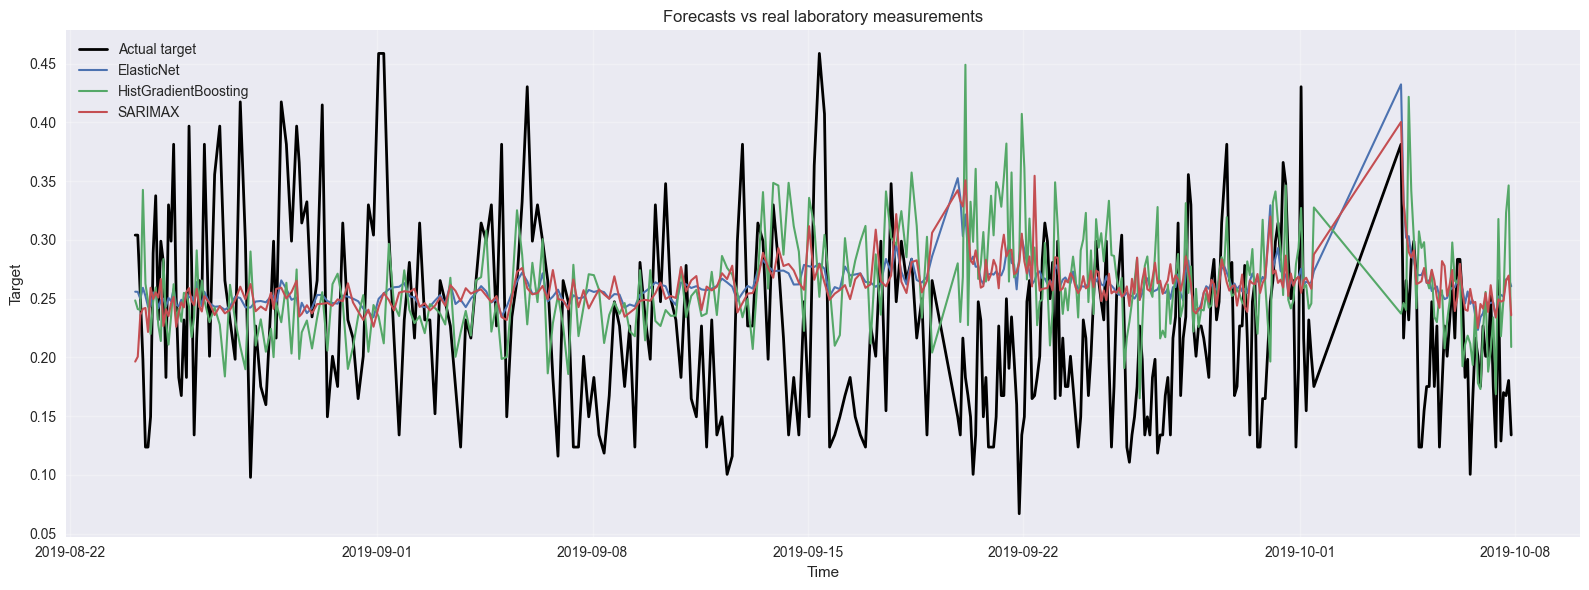

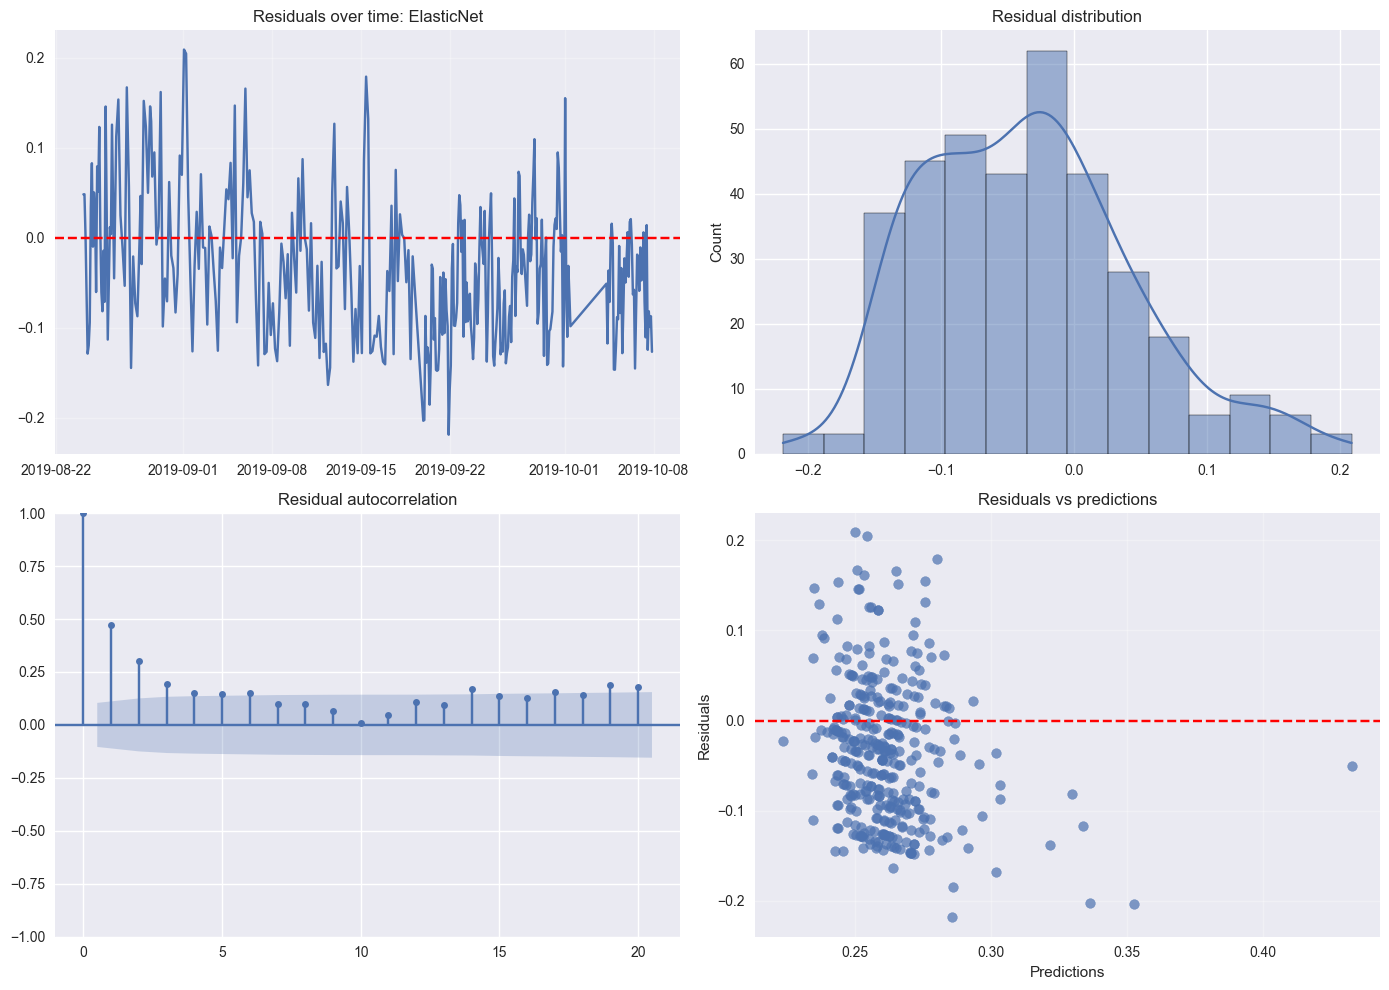

In [40]:
# Forecast visualization and residual analysis
plot_df = test_frame[["lab_datetime", "target"]].copy()
for model_name, y_pred in predictions.items():
    plot_df[model_name] = np.asarray(y_pred)

plt.figure(figsize=(16, 6))
plt.plot(plot_df["lab_datetime"], plot_df["target"], label="Actual target", linewidth=2, color="black")
for model_name in predictions:
    plt.plot(plot_df["lab_datetime"], plot_df[model_name], label=model_name, linewidth=1.5)
plt.title("Forecasts vs real laboratory measurements")
plt.xlabel("Time")
plt.ylabel("Target")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_pred = np.asarray(predictions[best_model_name])
residuals = np.asarray(y_test) - best_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(test_frame["lab_datetime"], residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title(f"Residuals over time: {best_model_name}")
axes[0, 0].grid(True, alpha=0.3)

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Residual distribution")

sm.graphics.tsa.plot_acf(residuals, lags=20, ax=axes[1, 0])
axes[1, 0].set_title("Residual autocorrelation")

axes[1, 1].scatter(best_pred, residuals, alpha=0.7)
axes[1, 1].axhline(0, color="red", linestyle="--")
axes[1, 1].set_title("Residuals vs predictions")
axes[1, 1].set_xlabel("Predictions")
axes[1, 1].set_ylabel("Residuals")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


,feature,importance,signed_coef
17,telemetry_0_roll_max_24,0.016187,-0.016187
19,telemetry_3_roll_max_24,0.010370,-0.010370
0,telemetry_0,0.000000,-0.000000
1,telemetry_0_lag_1,0.000000,-0.000000
3,telemetry_0_lag_3,0.000000,-0.000000
2,telemetry_0_lag_2,0.000000,-0.000000
4,telemetry_0_lag_6,0.000000,-0.000000
5,telemetry_0_lag_12,0.000000,-0.000000
8,telemetry_0_roll_max_3,0.000000,-0.000000
9,telemetry_0_roll_mean_6,0.000000,-0.000000


PermutationExplainer explainer: 201it [00:11,  1.80it/s]                         


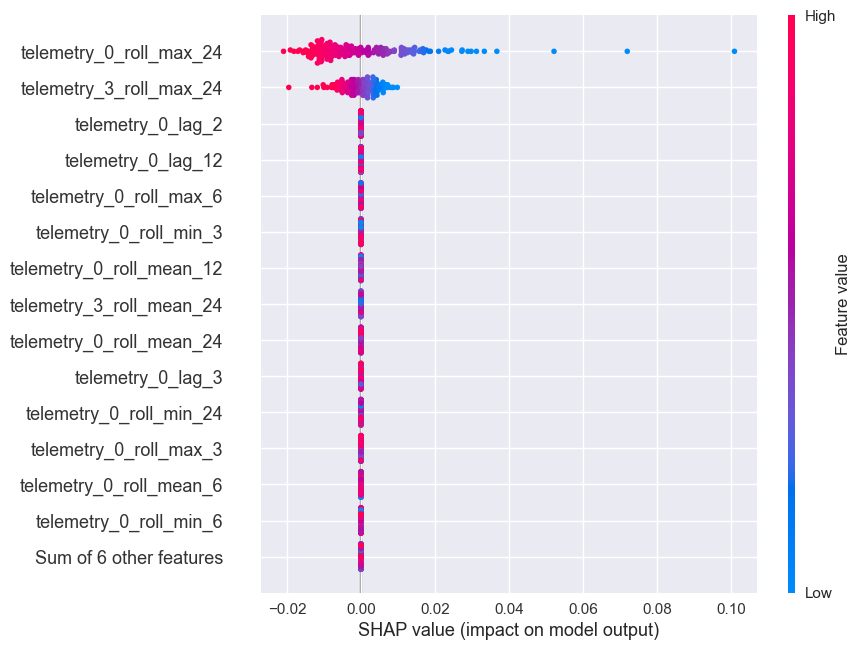

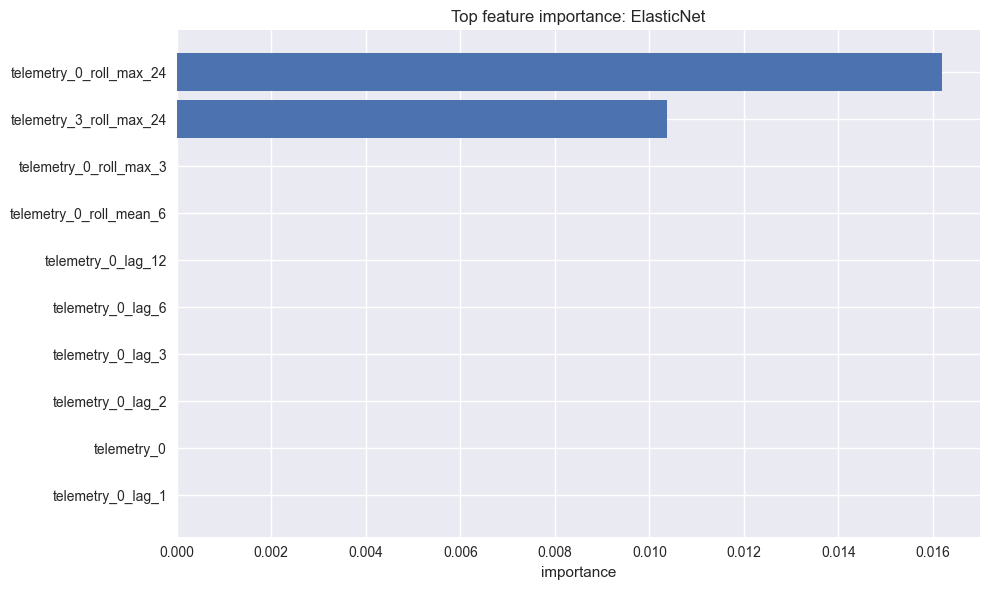

In [41]:
# Feature importance and interpretation
importance_frames = []

if best_model_name == "ElasticNet":
    coef = trained_models["ElasticNet"].named_steps["model"].coef_
    importance_df = pd.DataFrame({
        "feature": model_features,
        "importance": np.abs(coef),
        "signed_coef": coef,
    }).sort_values("importance", ascending=False)
    display(importance_df.head(15))
    importance_frames.append(importance_df.assign(model="ElasticNet"))

elif best_model_name == "HistGradientBoosting":
    perm = permutation_importance(
        trained_models["HistGradientBoosting"],
        X_test,
        y_test,
        n_repeats=15,
        random_state=42,
        scoring="neg_mean_absolute_error",
    )
    importance_df = pd.DataFrame({
        "feature": model_features,
        "importance": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance", ascending=False)
    display(importance_df.head(15))
    importance_frames.append(importance_df.assign(model="HistGradientBoosting"))

else:
    sarimax_importance = pd.DataFrame({
        "feature": sarimax_features,
        "coef": sarimax_result.params.reindex(sarimax_features).values,
    })
    sarimax_importance["importance"] = sarimax_importance["coef"].abs()
    sarimax_importance = sarimax_importance.sort_values("importance", ascending=False)
    display(sarimax_importance.head(15))
    importance_frames.append(sarimax_importance.assign(model="SARIMAX"))

try:
    import shap

    if best_model_name in {"ElasticNet", "HistGradientBoosting"}:
        sample_X = X_test.head(min(200, len(X_test))).copy()
        explainer = shap.Explainer(trained_models[best_model_name].predict, sample_X)
        shap_values = explainer(sample_X)
        shap.plots.beeswarm(shap_values, max_display=15)
except Exception as exc:
    print("SHAP could not be computed in the current environment:", exc)

if importance_frames:
    final_importance = importance_frames[0].copy()
    plot_col = "importance" if "importance" in final_importance.columns else "coef"
    top_features = final_importance.head(10).sort_values(plot_col)

    plt.figure(figsize=(10, 6))
    plt.barh(top_features["feature"], top_features[plot_col])
    plt.title(f"Top feature importance: {best_model_name}")
    plt.xlabel(plot_col)
    plt.tight_layout()
    plt.show()


## Интерпретация результатов и физический смысл признаков

По итогам текущего сравнения лучшей моделью оказался `ElasticNet`. Это важно для интерпретации: в отличие от бустинга, здесь можно напрямую анализировать знаки и величины коэффициентов и понимать, какие признаки модель реально использует в прогнозе.

В текущем ноутбуке среди лидирующих признаков у `ElasticNet` оказались прежде всего rolling-максимумы на длинном окне, например `telemetry_0_roll_max_24` и `telemetry_3_roll_max_24`. Это означает, что модель сильнее реагирует не на мгновенное значение сигнала, а на недавние локальные пики соответствующих технологических каналов. С инженерной точки зрения это похоже на ситуацию, когда качество чувствительно к кратковременным перегрузкам или выходам параметра на повышенный уровень в течение предшествующего интервала.

Если в других экспериментах значимыми становятся признаки динамики (`diff`, `growth_rate`, `derivative`), это означает, что для прогноза важен не только уровень параметра, но и скорость его изменения. В физическом смысле это соответствует переходным режимам, разгонам и резким коррекциям, которые могут влиять на качество сильнее, чем стационарные участки.